This notebook fits by-cre models on the shendure data & demonstrates that estimated nb parameters track closely with UMI means, as expected.

The matrix-creation and fitting code is independent of the main scMPRA package, since its this analysis that informed the package code.

In [18]:
#imports
import pandas as pd
import numpy as np
import time
import pickle
from formulaic import Formula
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress
from tensorzinb.tensorzinb import TensorZINB
import scMPRAforge as scm

import tqdm

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
shendure=scm.scMPRA_data.from_tsv(f"{data_root}/shendure/shendure_counts_grouped.txt")

In [4]:
shendure.set_negative_controls(["minP","noP"])

In [5]:
shendure.ortho_filter()

In [11]:
def tensorzinb_fit(matricies):
    """
    Takes matricies as returned by `create_matricies` & produces a tensorzinb model
    """
    zinbo = TensorZINB(endog=matricies["regressand"]["umis_mpra_bc"].to_numpy().reshape((-1, 1)),
                       exog=matricies["nb_regressors"].to_numpy(),
                       exog_infl=matricies["zi_regressors"].to_numpy(),)
                       #exog_c=matricies["shared_regressors"],
                       #exog_infl_c=matricies["shared_regressors"])  # ,same_dispersion=True
    zinb_result = None
    try:
        zinb_result = zinbo.fit(init_method="nb")
    except pd.errors.InvalidIndexError:
        return "index_error"

    return zinb_result

def create_matricies(nb_formula,zi_formula,scmpra):
    """
    Takes a scMPRA_data object & formulas & produces design matricies. 
    """
    data=scmpra
    y, X=Formula(nb_formula).get_model_matrix(data,output='pandas')
    Z=Formula(zi_formula).get_model_matrix(data,output='pandas')
    return {
        'nb_regressors':X,
        'regressand':y,
        'zi_regressors':Z
    }

In [19]:
first_time=True
QC={}


if first_time:
    
    #loop through all cell-types, produce 
    for cre_id in tqdm.tqdm(shendure.data["cre_id"].unique()):
        print(cre_id)

        ##subset to current cell-type##
        shendure_subset=shendure.data[shendure.data["cre_id"]==cre_id]

        if len(shendure_subset['cell_type'].unique())<2:
            #in our little demo, we will just skip cases where filtering means that we only have one cell-type left.
            #These can be used to simulate but not for tests.
            continue
        
        ## create design matricies ##
        matricies=create_matricies(nb_formula="umis_mpra_bc ~ C(cell_type)",
                            zi_formula="C(rep_id)-1",
                            scmpra=shendure_subset)
        
        
        ## take the mean for comparison##
        shendure_mean=shendure_subset.groupby("cell_type")["umis_mpra_bc"].agg("mean").sort_values()

        ## fit a model##
        model=tensorzinb_fit(matricies)

        if model=="index_error":
            print("index error")
            continue

        ## compute predictions of mu from the model ##
        linear_mu=matricies["nb_regressors"].to_numpy() @ model["weights"]["x_mu"]
        mu_predictions=np.exp(linear_mu)

        #compute predictions of ZI from the model
        #linear_zi=(matricies["zi_regressors"].to_numpy() @ model["weights"]["x_pi"])
        #zi_predictions=linear_zi=1/(1+np.exp(-linear_zi))

        ## get the names of the cell-types ##
        cell_labeling=scm.undo_one_hot_encoding(matricies["nb_regressors"])["cell_type"]
        cell_labeling=cell_labeling.str.removeprefix("T.")

        ## label the predictions with CRE names ##
        mu_predictions_df=pd.DataFrame({'cell_type':cell_labeling,'mu':mu_predictions.squeeze()})
        mu_predictions_df.sort_values(by='mu')

        ## merge means & predicted mu into one df for convienient plotting ##
        mu_summary=mu_predictions_df.groupby("cell_type").agg("mean")
        mu_summary = mu_summary.merge(shendure_mean.rename_axis('cell_type').reset_index(), on='cell_type', how='left')
        
        ### Regress & store data for plotting ###
        
        x = mu_summary["umis_mpra_bc"]
        y = mu_summary["mu"]

        # Fit regression
        slope, intercept, r_value, p_value, std_err = linregress(x, y)

        #store regression info
        ret={'x':x,
            'y':y,
            'model':model,
            'slope':slope,
            'intercept':intercept,
            'r_value':r_value,
            'p_value':p_value,
            'std_err':std_err
        }
        
        QC[cre_id]=ret
    with open(f"{data_root}/shendure/cache_cre.pkl","wb") as f:
        pickle.dump(QC,f)
else:
    #not first time
    with open(f"{data_root}/shendure/cache_cre.pkl","rb") as f:
        QC=pickle.load(f)

  0%|          | 0/208 [00:00<?, ?it/s]

Gata4_chr14_5710


  0%|          | 1/208 [00:15<54:30, 15.80s/it]

Klf4_chr4_3952


  1%|          | 2/208 [00:31<53:46, 15.67s/it]

...

 99%|█████████▉| 206/208 [1:49:56<01:34, 47.42s/it]

Col1a1_chr11_15269


100%|█████████▉| 207/208 [1:50:44<00:47, 47.66s/it]

Txndc12_chr4_7969


100%|██████████| 208/208 [1:51:33<00:00, 32.18s/it]


Let's examine the min & max estimates for each cell-type to make sure they are in the right ballpark.

In [20]:
for cell_type in QC:
    dat=QC[cell_type]["y"]
    print(f"{cell_type} : {min(dat)} to {max(dat)}")

Gata4_chr14_5710 : 0.011854998750949308 to 0.07714011142789931
Klf4_chr4_3952 : 0.02296642382906091 to 0.2647416441258153
Lama1_chr17_7793 : 0.15788543488638215 to 0.5637336427070833
Sox17_chr1_67 : 0.035111369293618154 to 0.4847452889715853
Sox17_chr1_82 : 0.07359627687154069 to 0.3278667093644829
Sparc_chr11_7203 : 0.0917545339252258 to 0.9109356711991929
Sparc_chr11_7235 : 1.2032434009131774 to 5.8187148508422295
negative_control : 0.011531019202749699 to 0.30585224199188826
Bend5_chr4_8170 : 0.05269622047354873 to 0.3239495957083354
Bend5_chr4_8199 : 0.009277055598260092 to 0.262838439384421
Bend5_chr4_8201 : 0.008396537699002844 to 1.571666082521931
Btg1_chr10_9572 : 0.07904763416289909 to 0.08610272308648602
Btg1_chr10_9588 : 0.012663510692472853 to 0.09693276633466454
Col5a1_chr2_2558 : 0.01382653483357687 to 0.07223325779544112
Col5a1_chr2_2565 : 0.01421247007137818 to 0.10240802139394685
Col5a1_chr2_2576 : 0.03082093566689598 to 0.14184072242414061
Epas1_chr17_10056 : 0.017176

All in the right ballpark!

Let's examine the correlations between data mean & estimated mu parameters...

In [21]:
for cell_type in QC:
    print(f"{cell_type} : r={QC[cell_type]['r_value']}, slope={QC[cell_type]['slope']}")

Gata4_chr14_5710 : r=0.9996845884540243, slope=2.2078049951844405
Klf4_chr4_3952 : r=-0.8152416709320341, slope=-35.85002315859606
Lama1_chr17_7793 : r=0.9972316801596052, slope=1.6596607348910952
Sox17_chr1_67 : r=0.9994376588230969, slope=1.8797470269769805
Sox17_chr1_82 : r=0.9978737303313551, slope=1.939247179348005
Sparc_chr11_7203 : r=0.9994959181912066, slope=1.5921579582083338
Sparc_chr11_7235 : r=0.9921071514208658, slope=0.9830719893631528
negative_control : r=0.9998994154230099, slope=1.1453242867621514
Bend5_chr4_8170 : r=1.0, slope=1.887411668589577
Bend5_chr4_8199 : r=0.9935239016756896, slope=1.7598101285018921
Bend5_chr4_8201 : r=0.999474554490825, slope=0.6592566099692589
Btg1_chr10_9572 : r=-1.0, slope=-0.7088060074510152
Btg1_chr10_9588 : r=0.9935647029494898, slope=2.0805700840187527
Col5a1_chr2_2558 : r=0.9604786625092786, slope=1.6411015101520594
Col5a1_chr2_2565 : r=0.9974662878627886, slope=2.015600762551574
Col5a1_chr2_2576 : r=0.9990931832287223, slope=1.78812

Correlations look very good. Let's check for outliers:

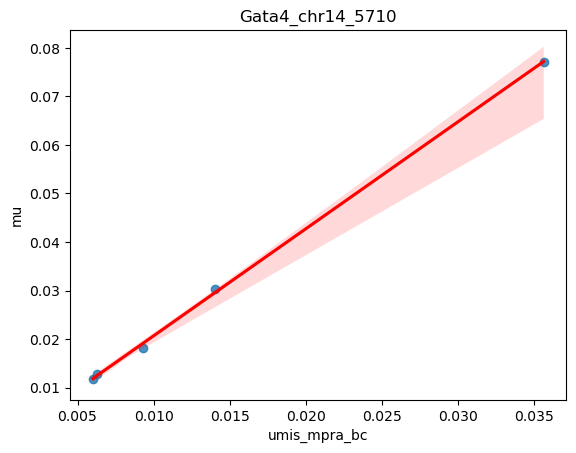

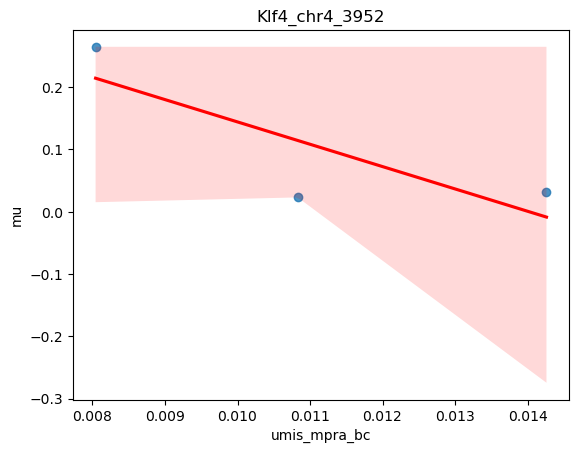

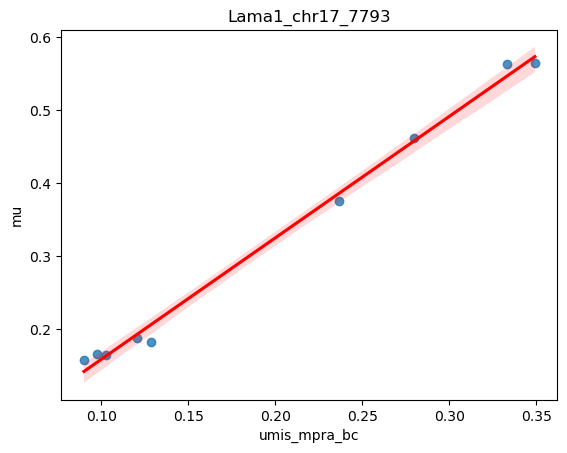

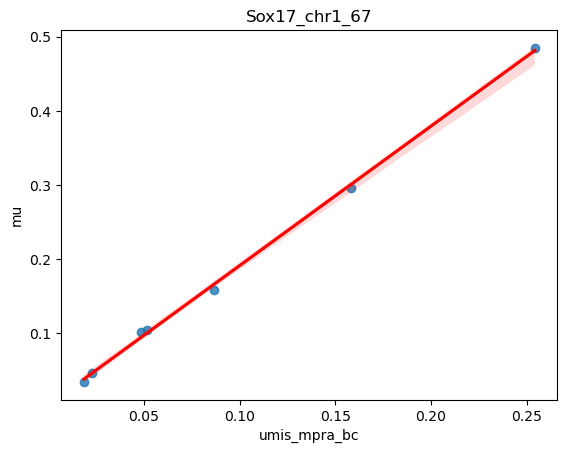

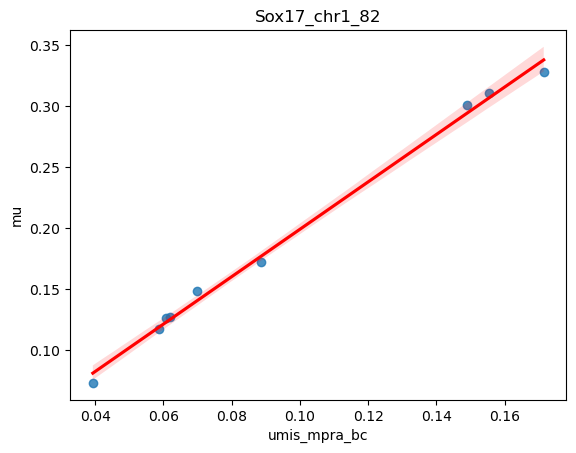

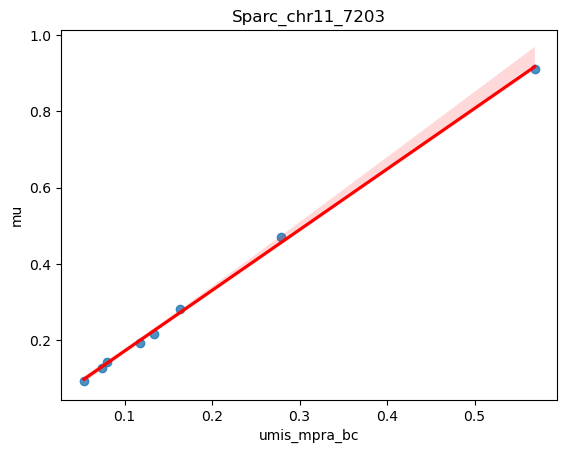

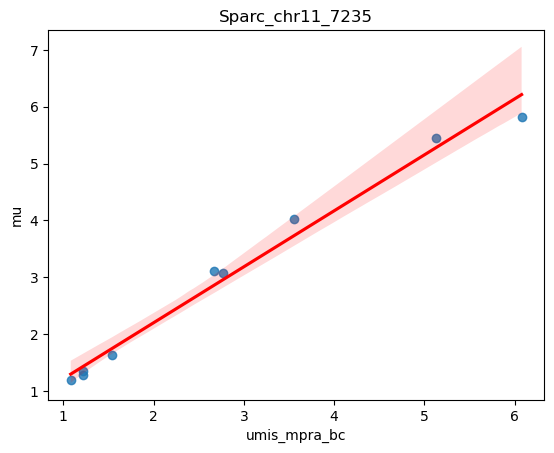

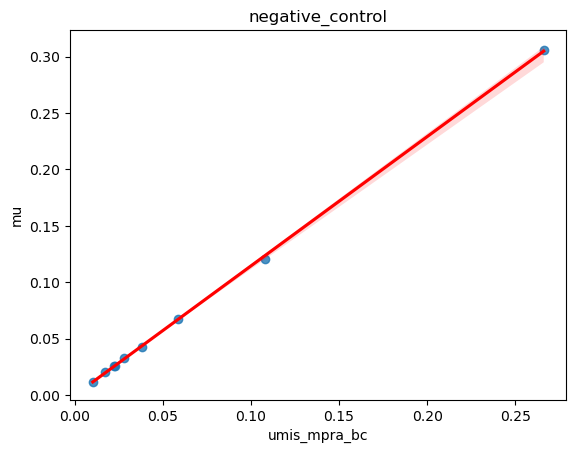

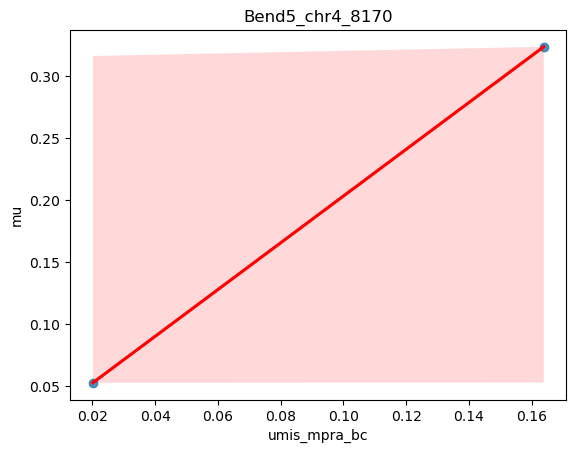

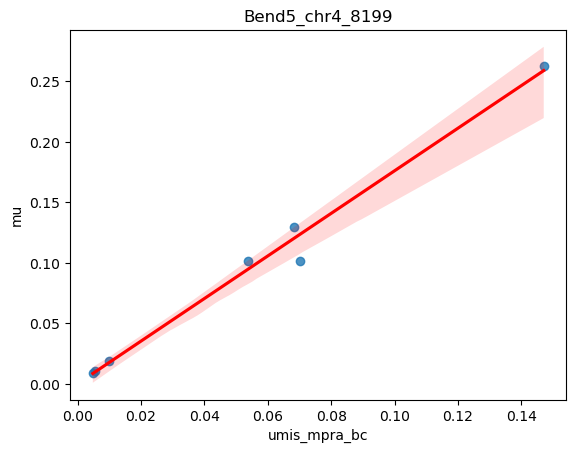

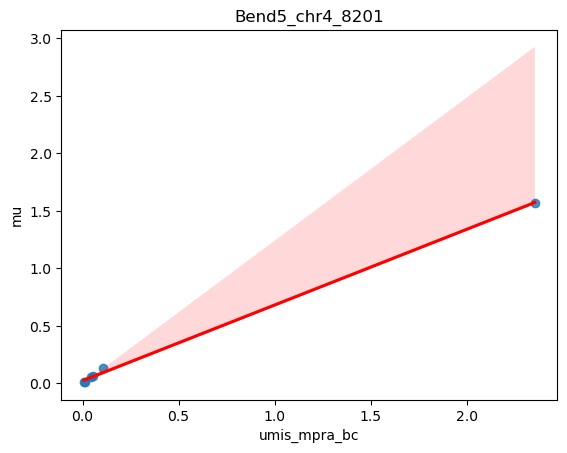

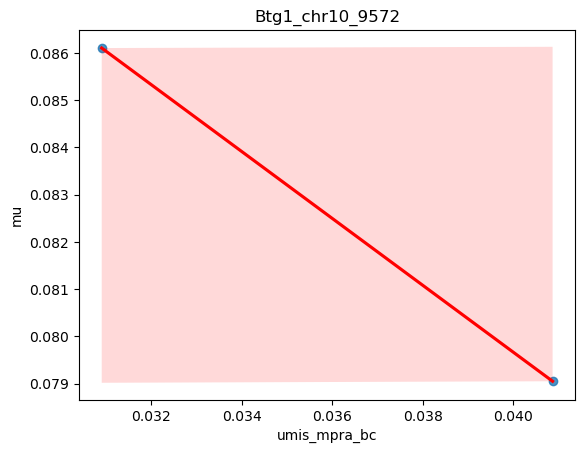

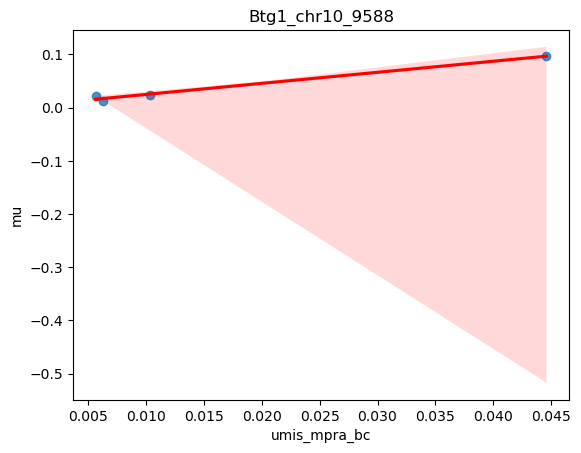

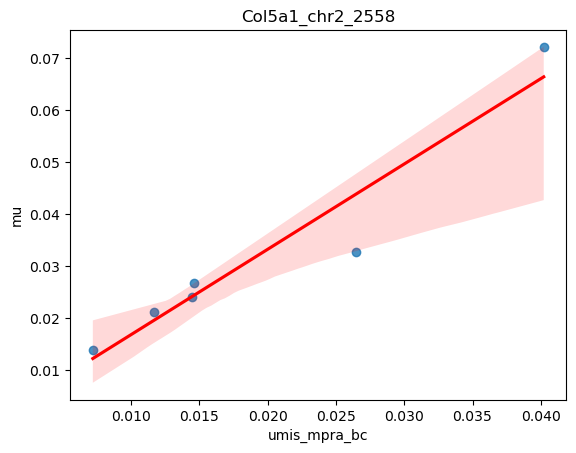

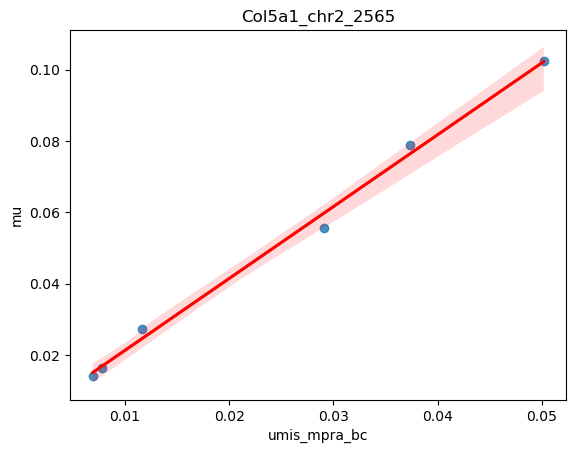

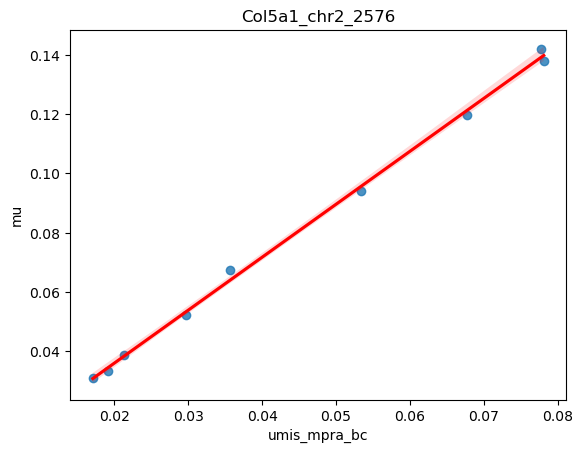

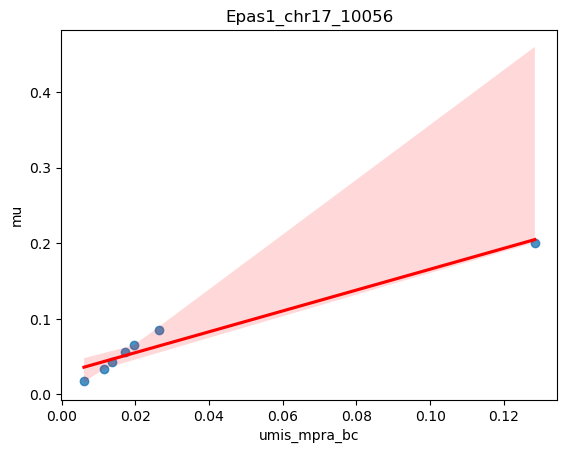

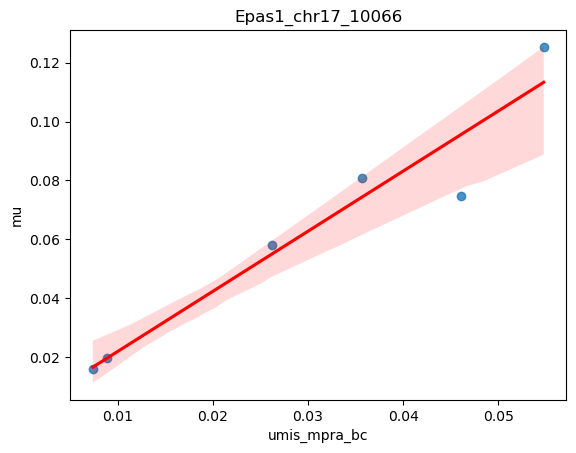

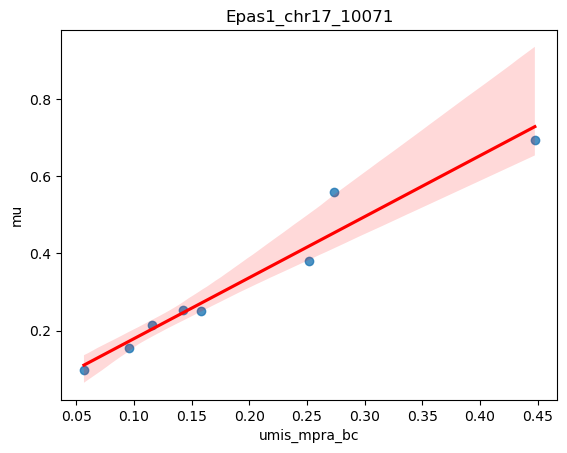

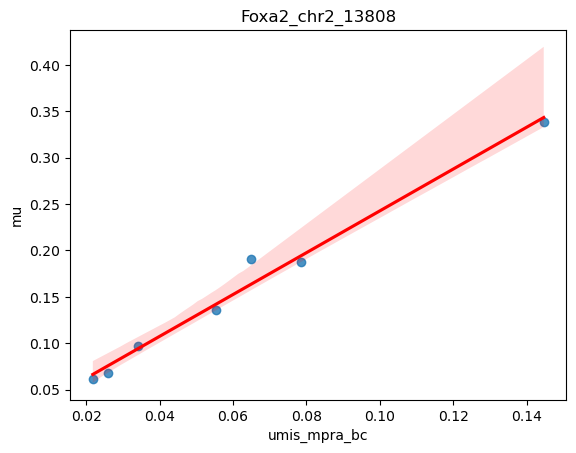

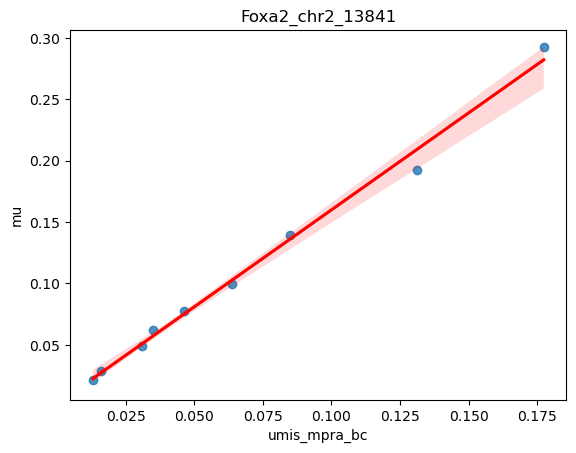

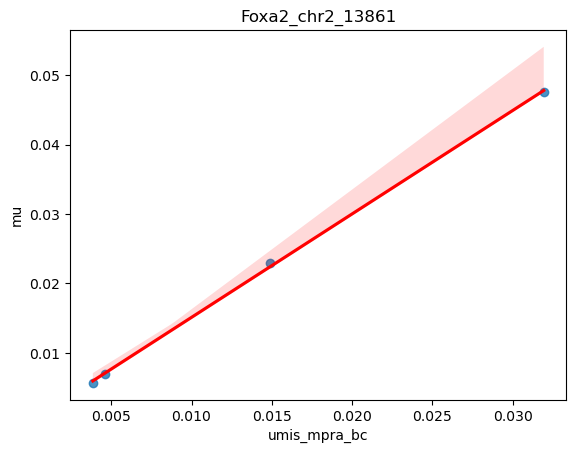

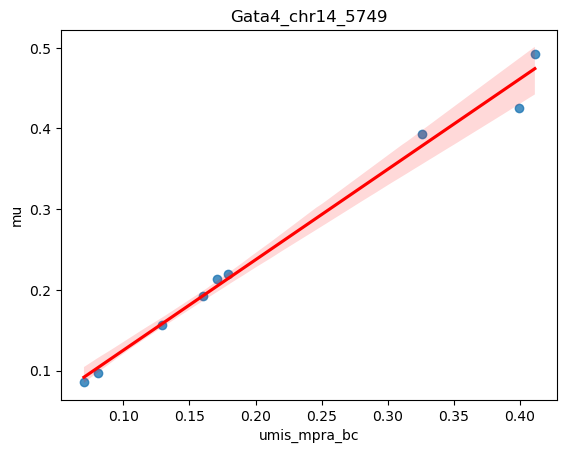

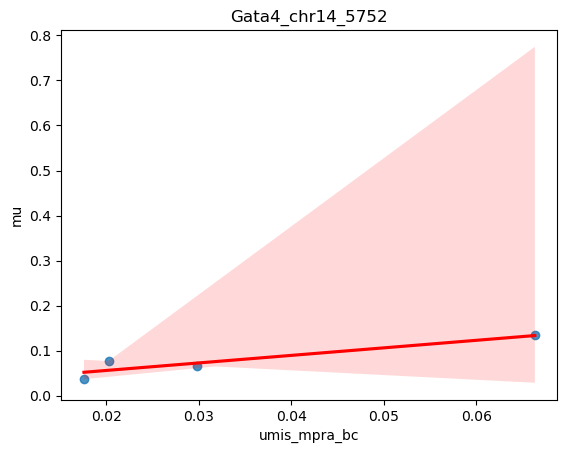

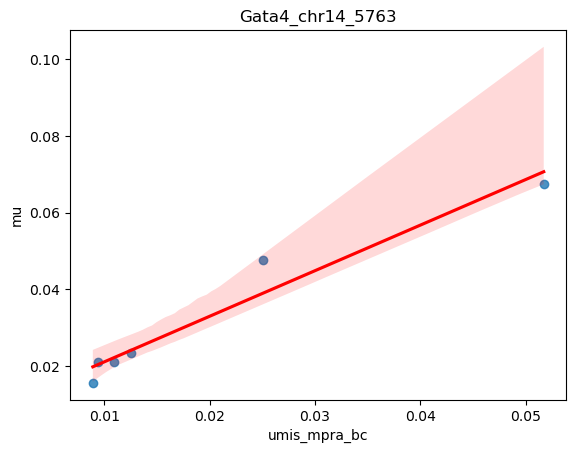

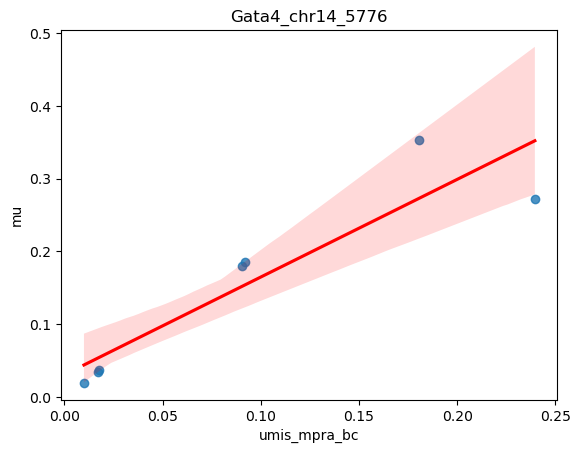

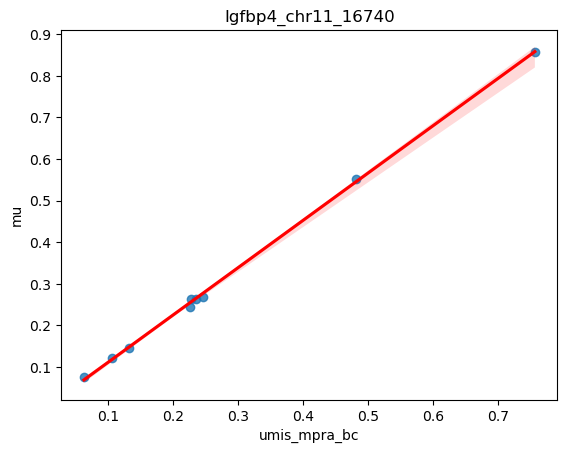

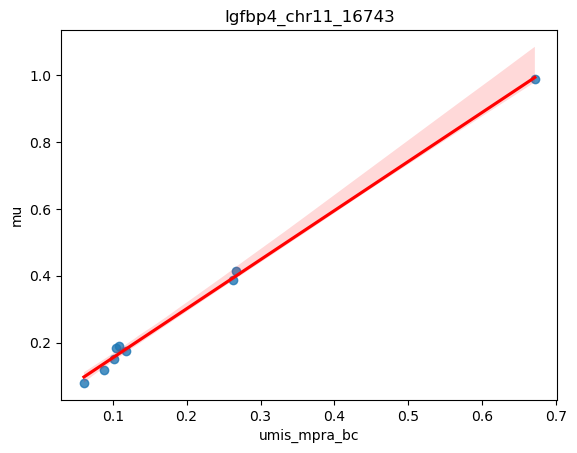

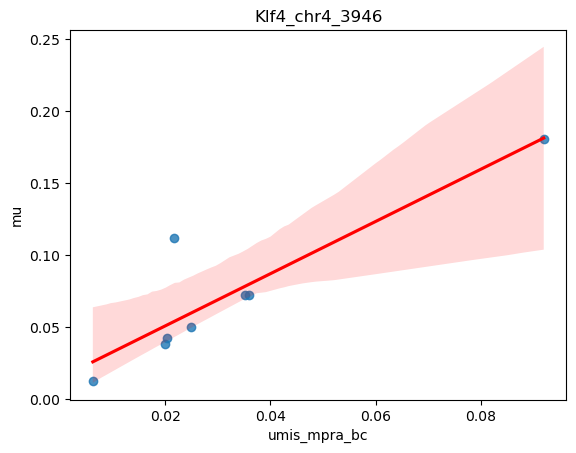

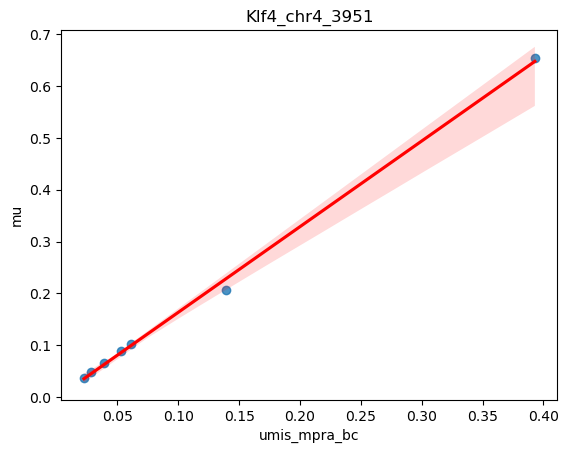

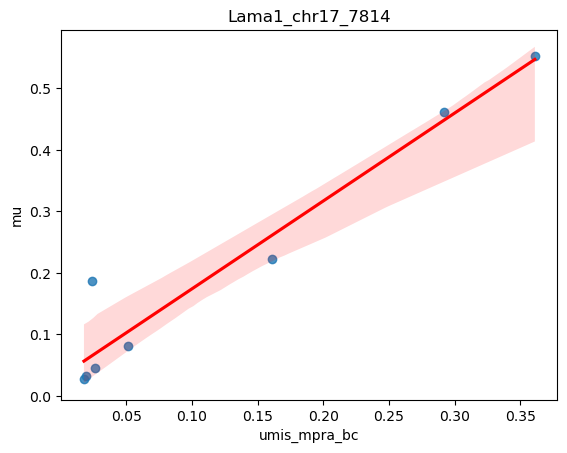

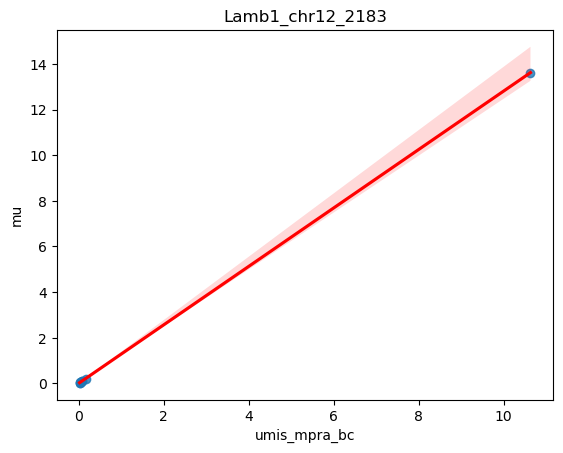

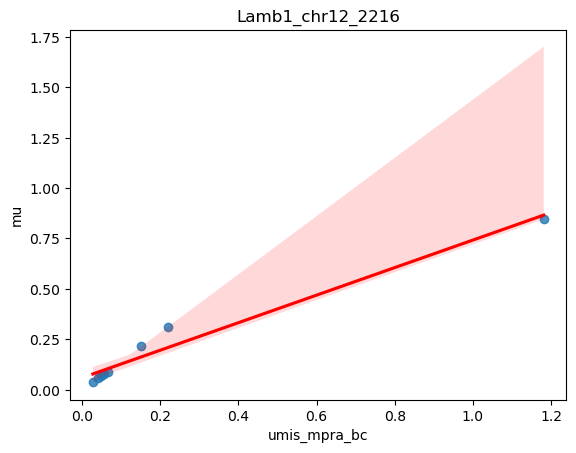

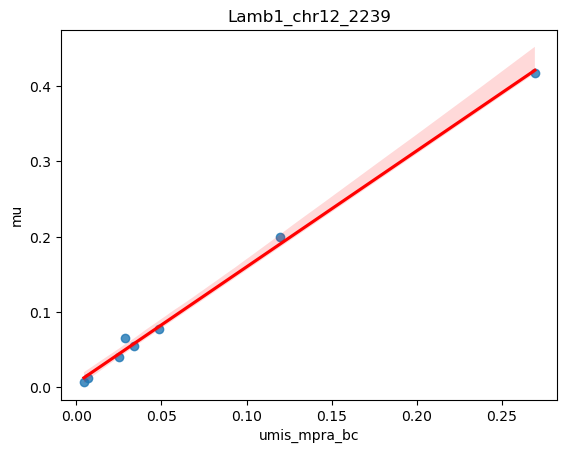

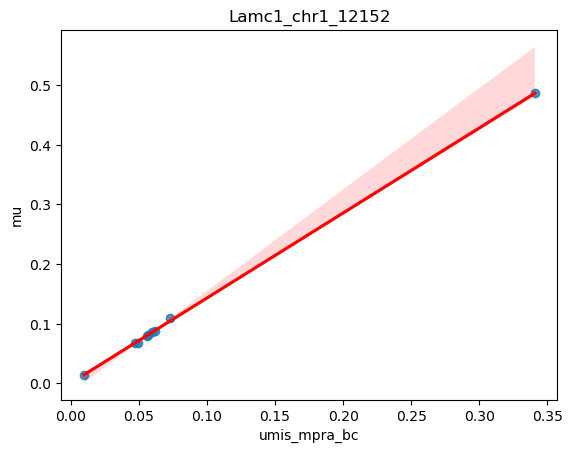

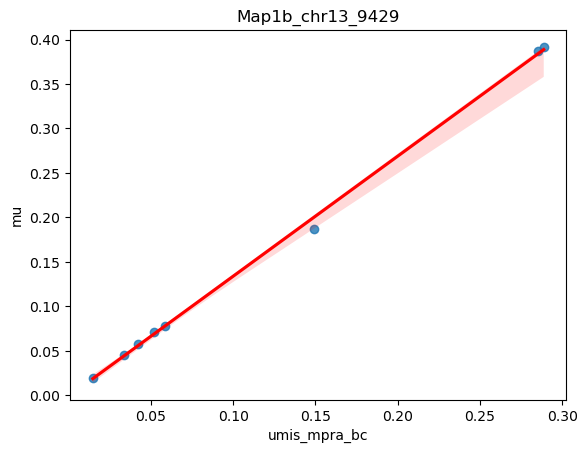

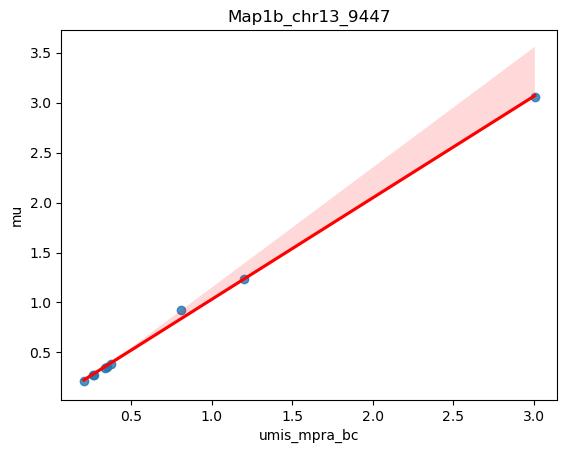

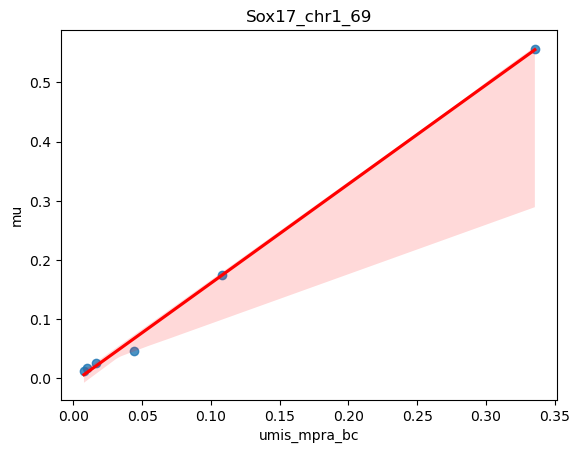

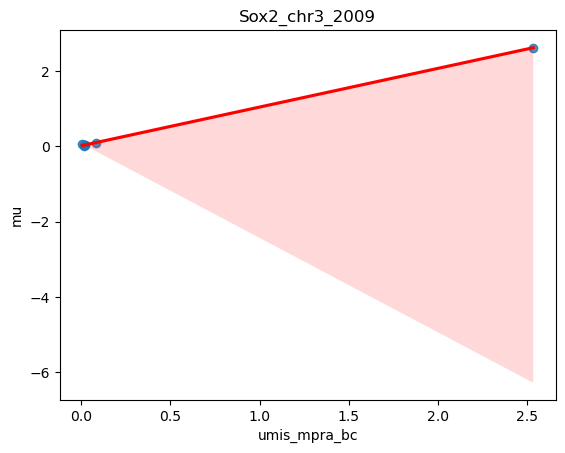

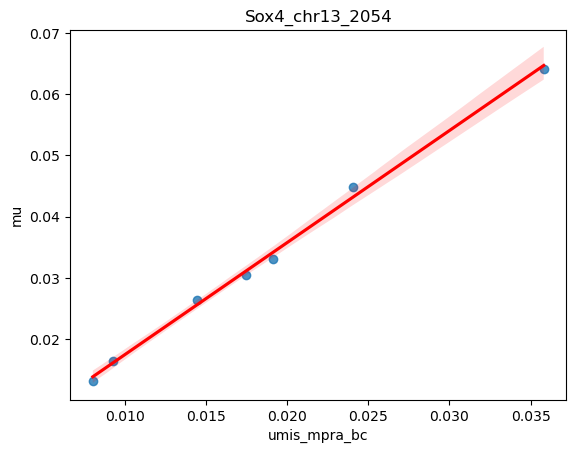

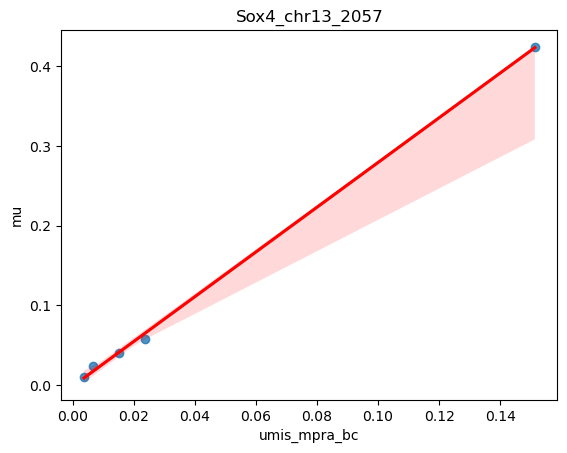

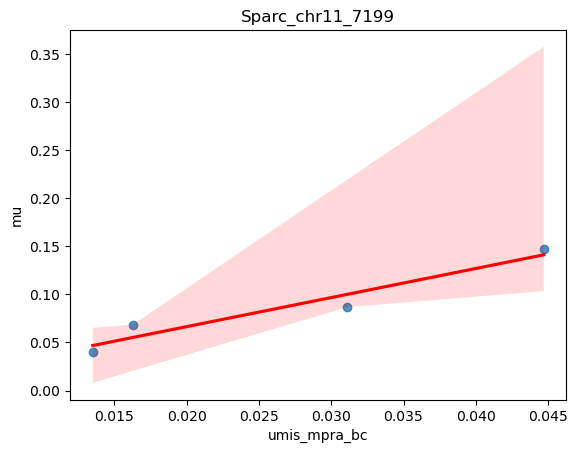

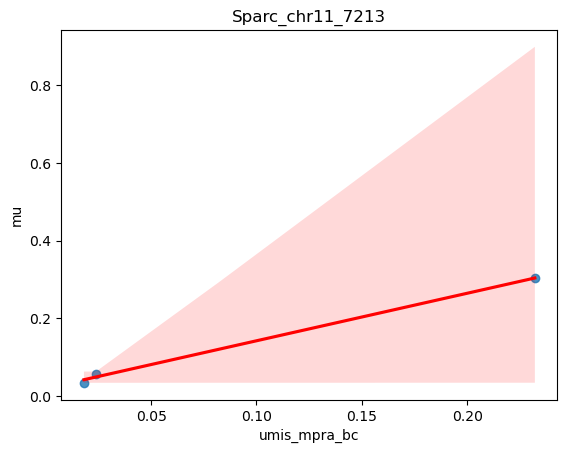

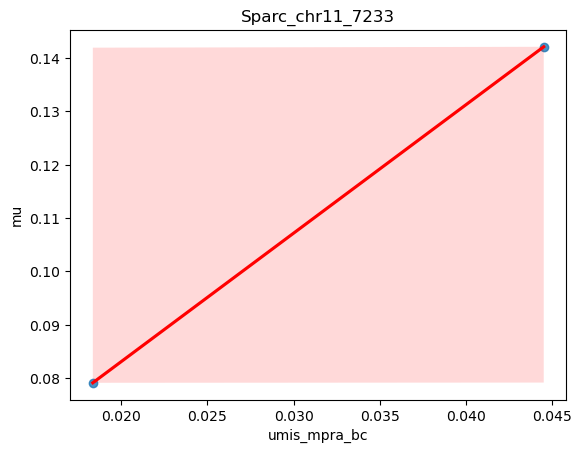

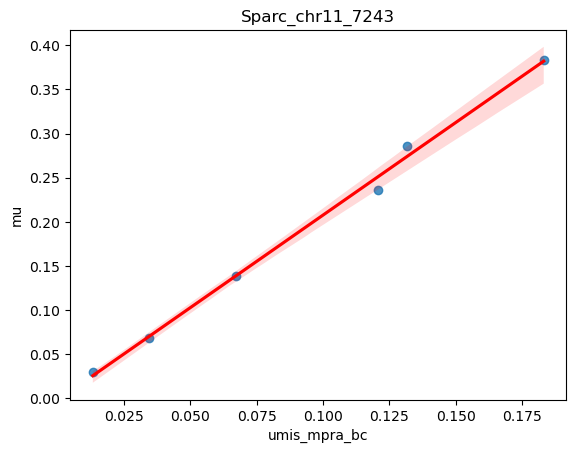

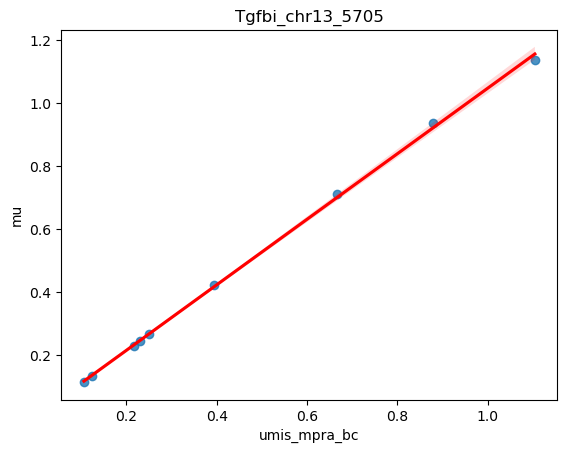

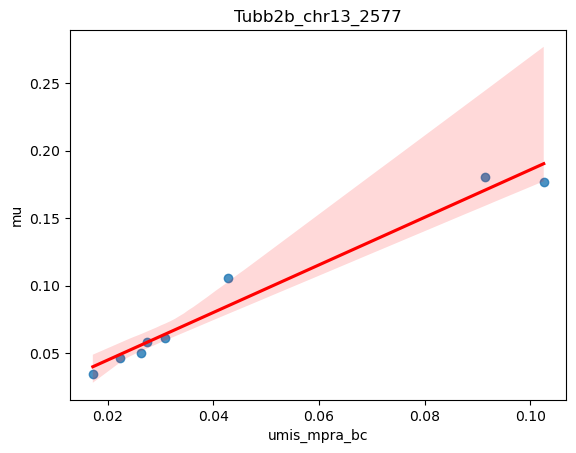

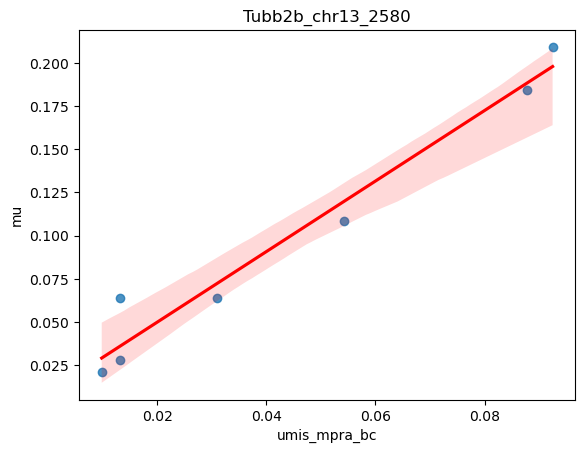

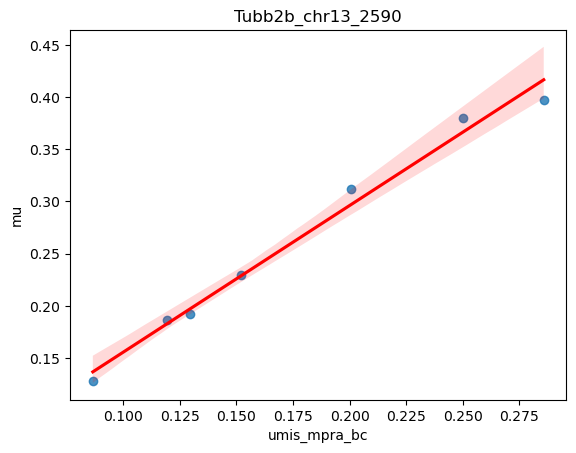

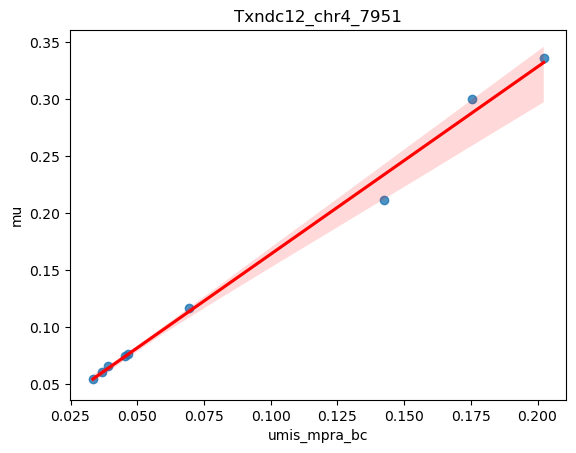

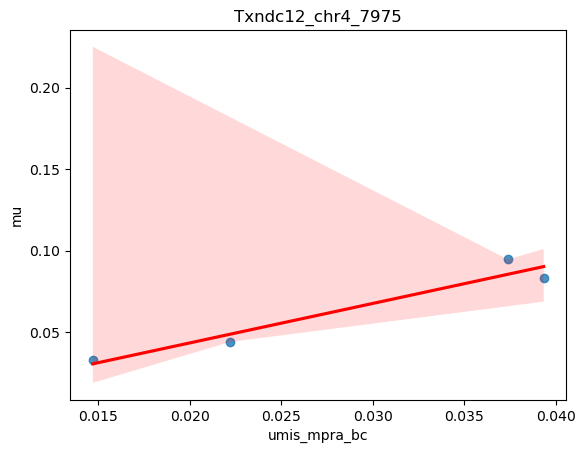

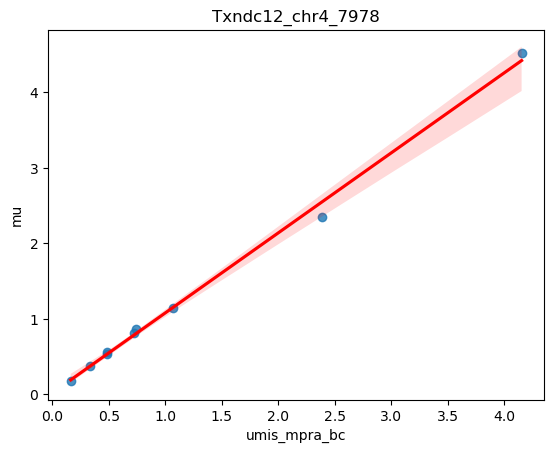

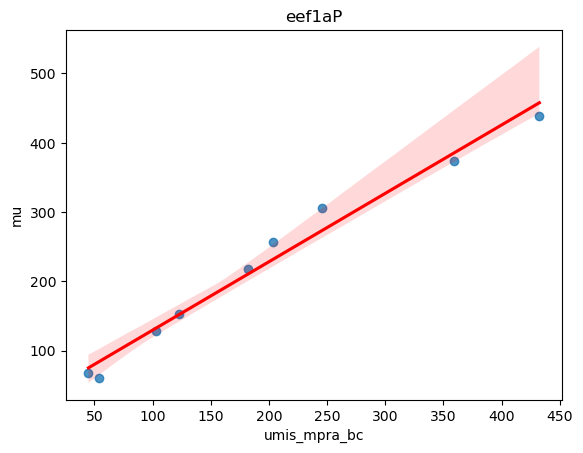

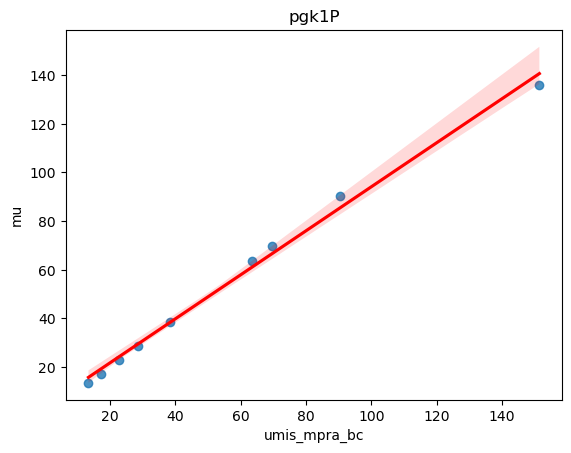

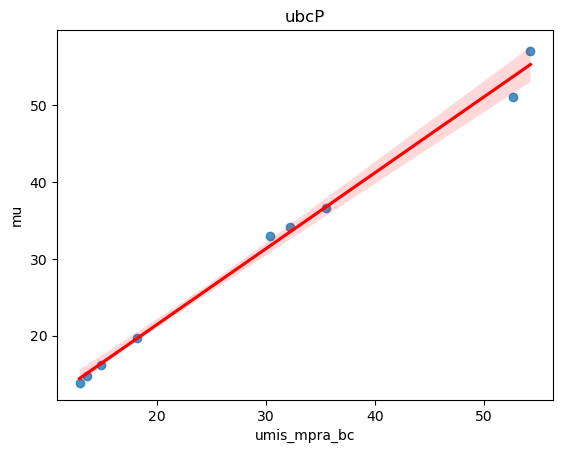

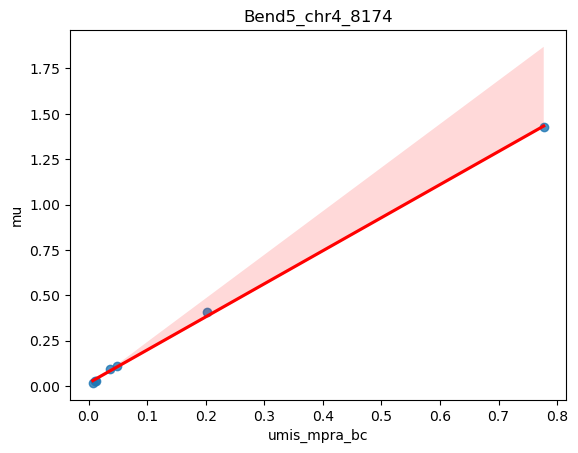

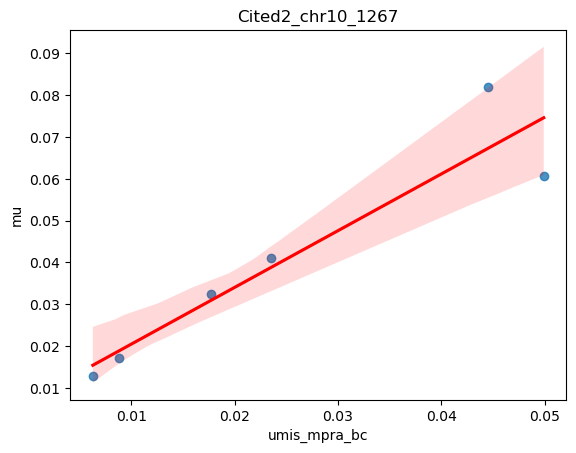

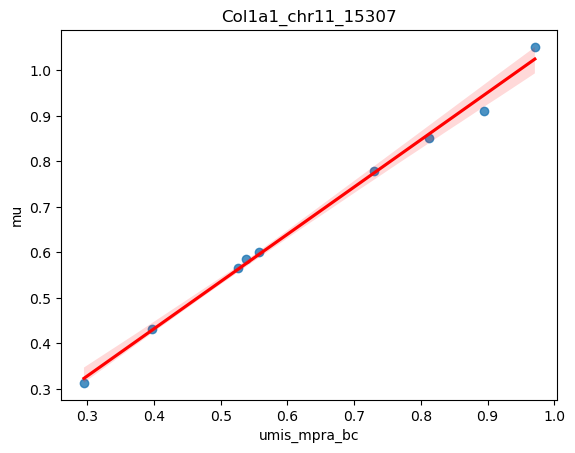

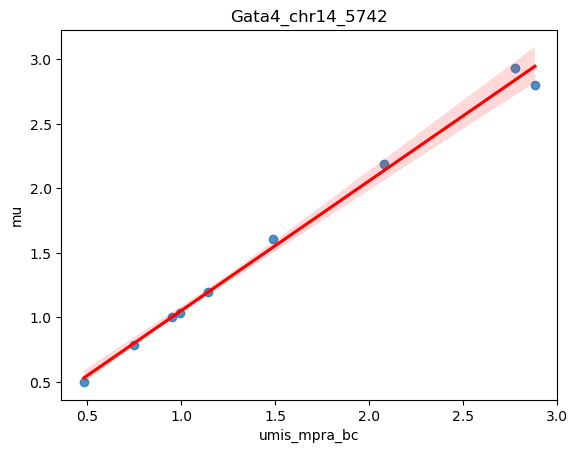

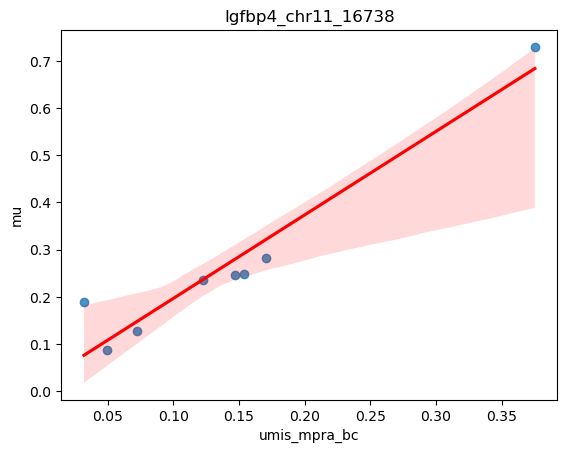

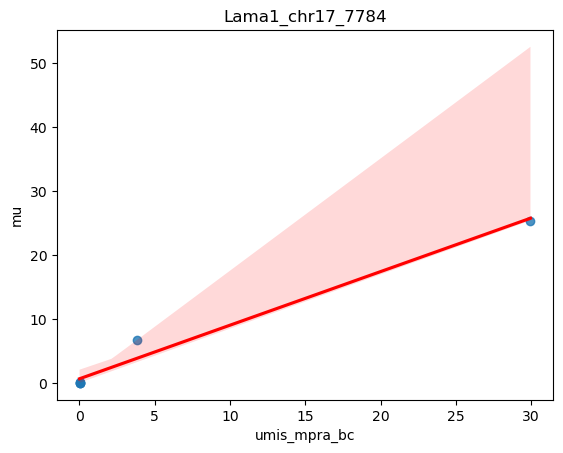

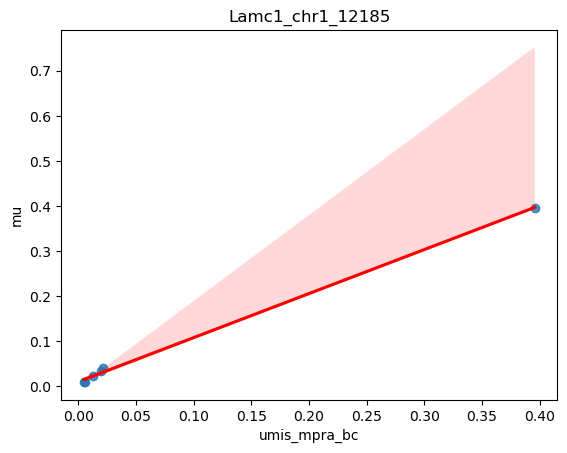

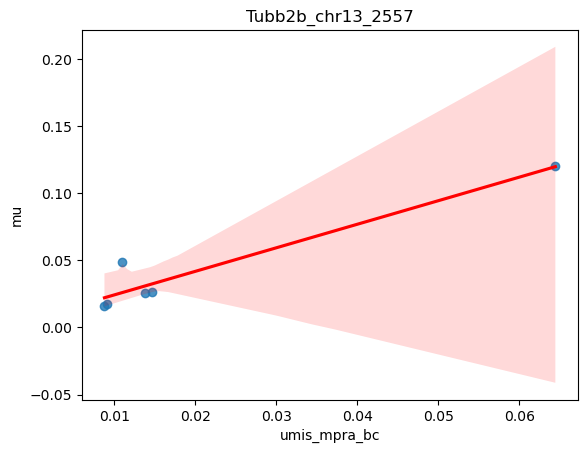

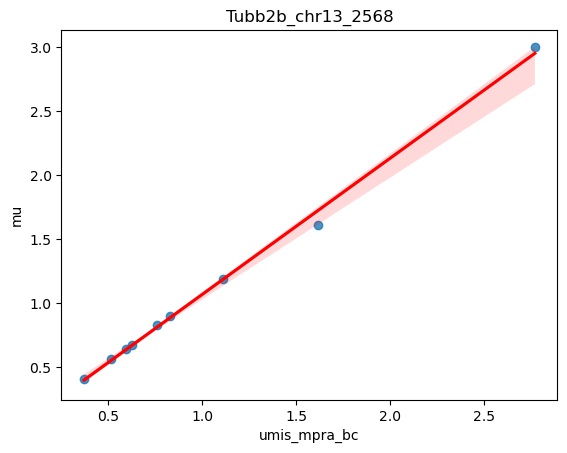

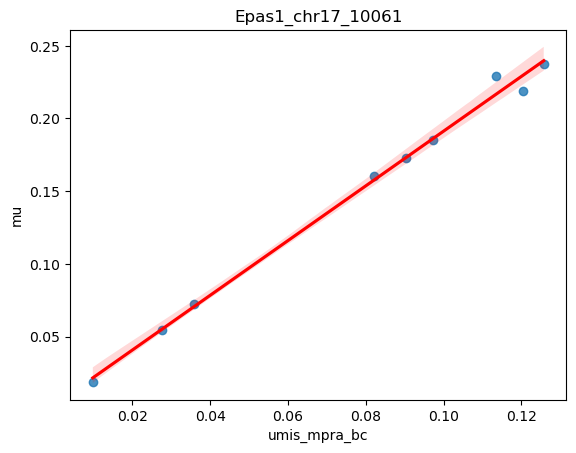

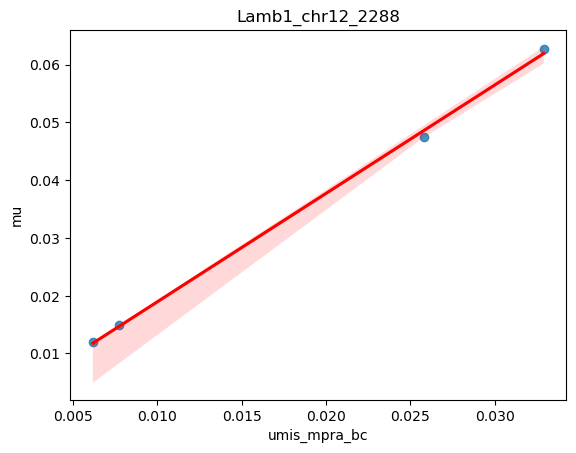

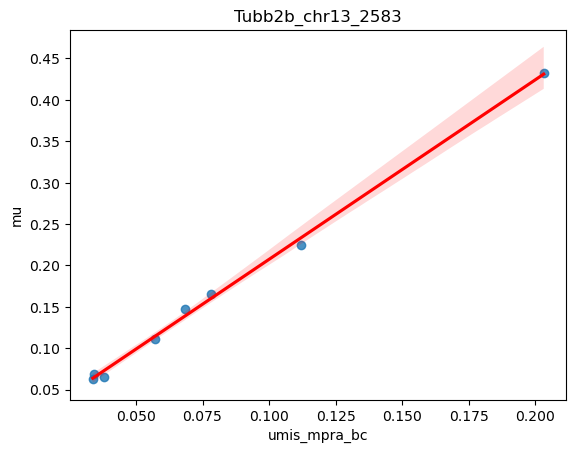

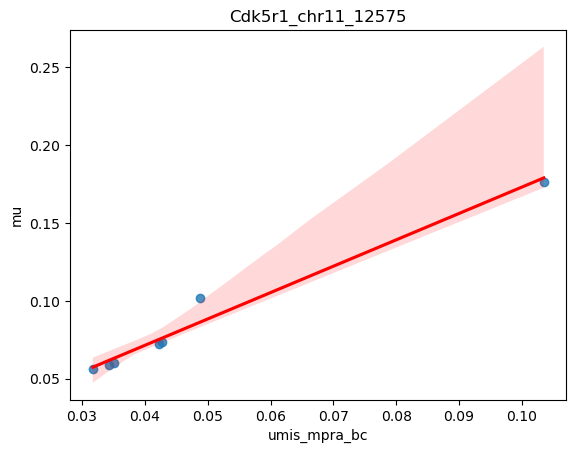

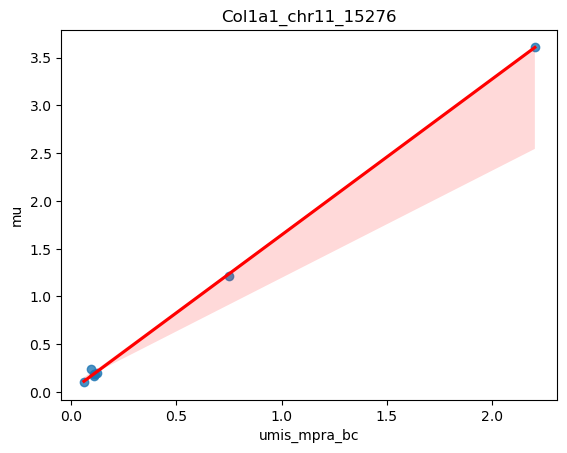

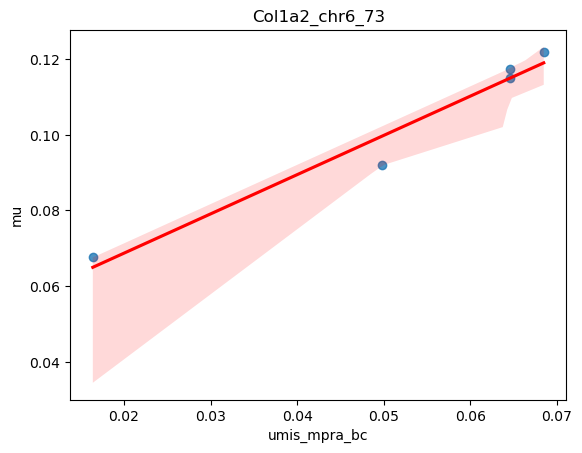

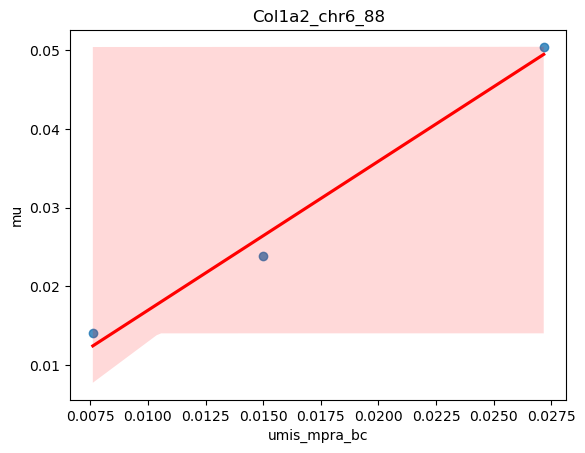

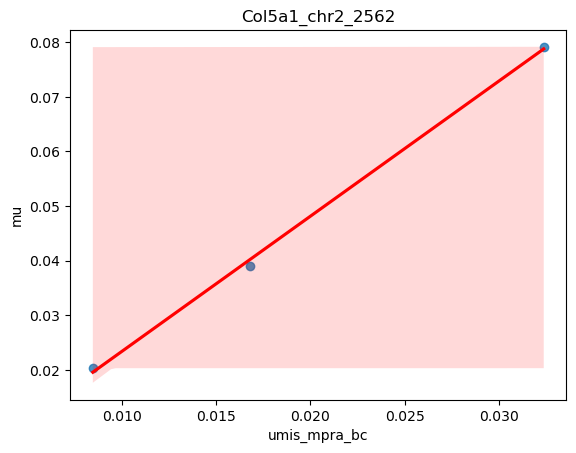

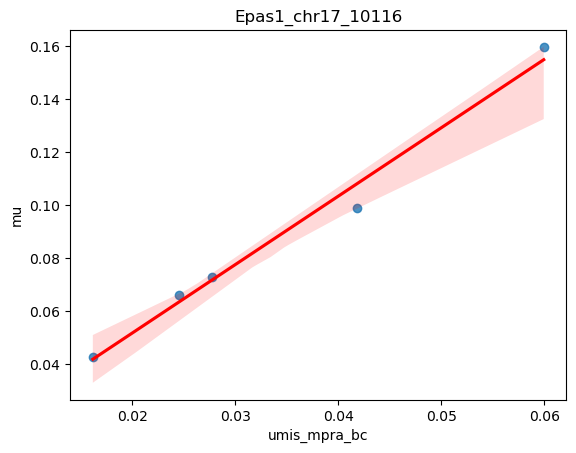

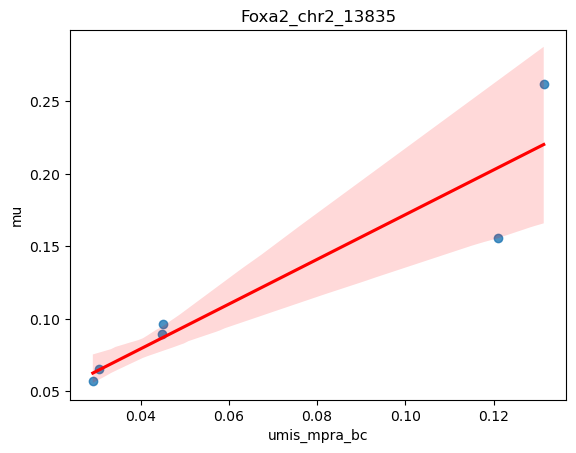

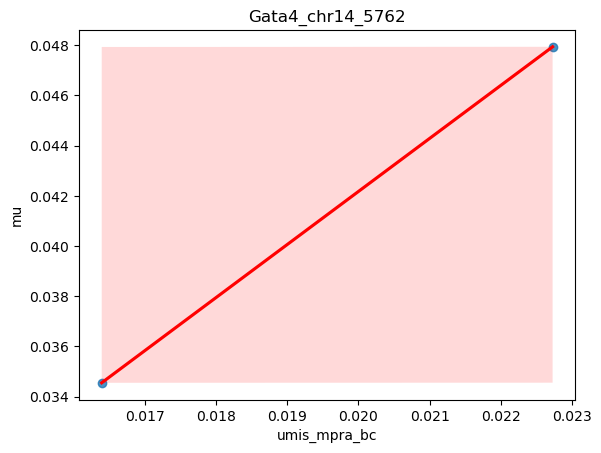

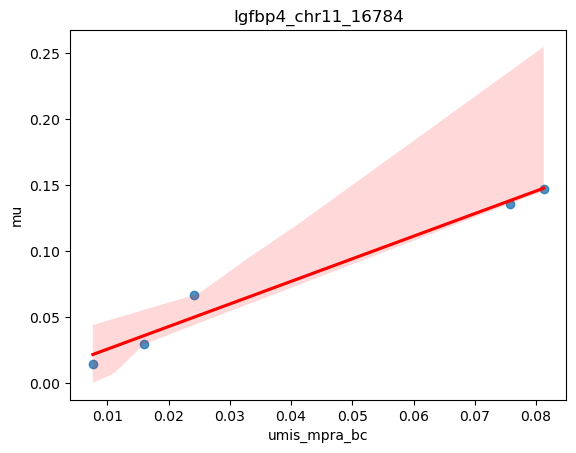

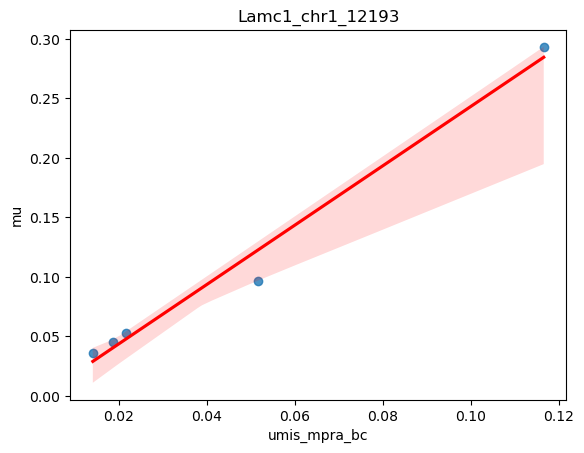

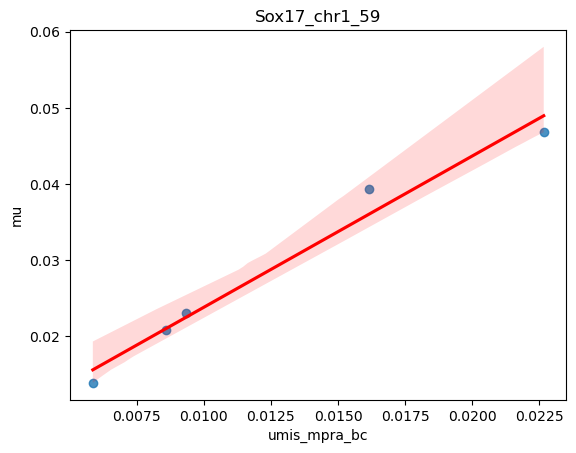

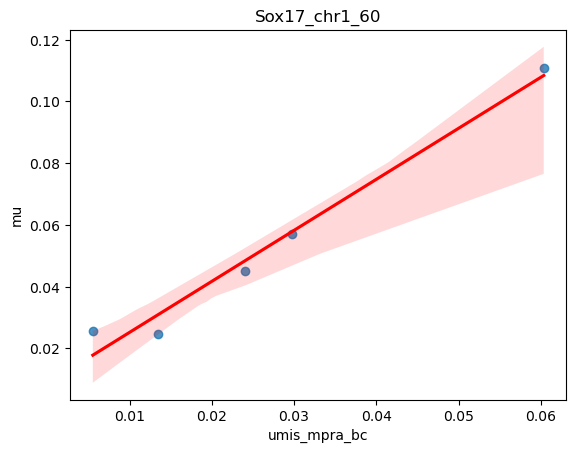

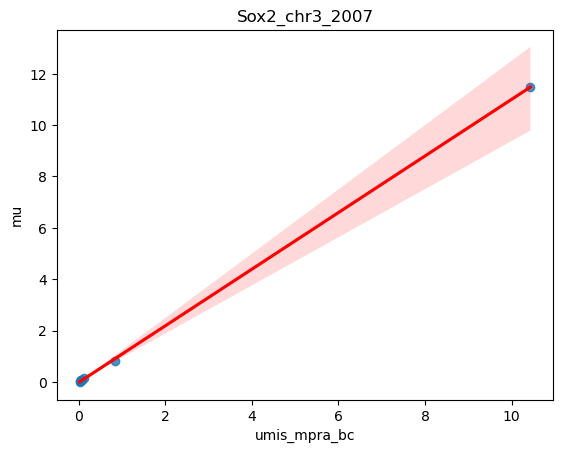

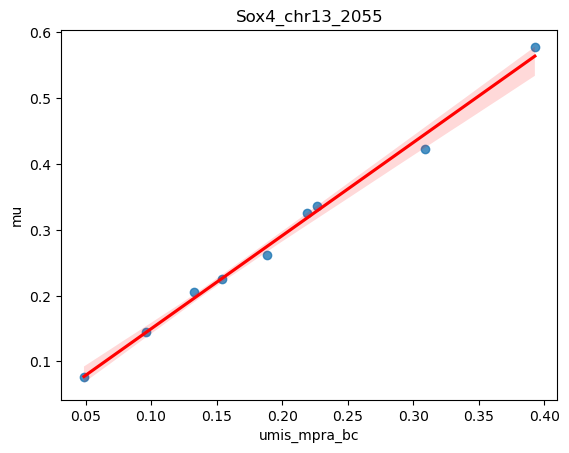

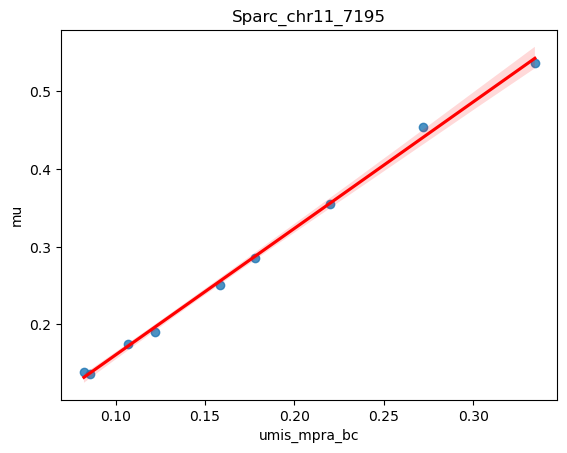

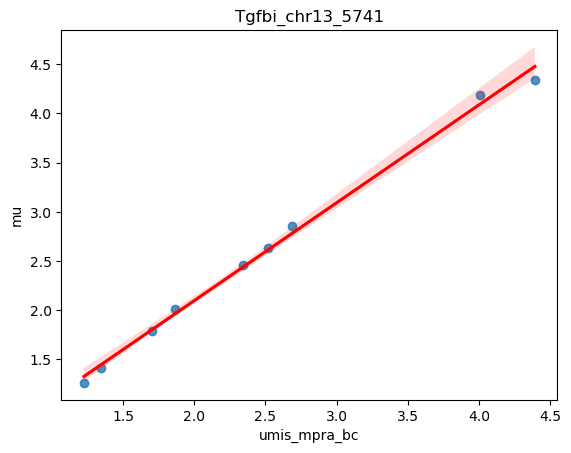

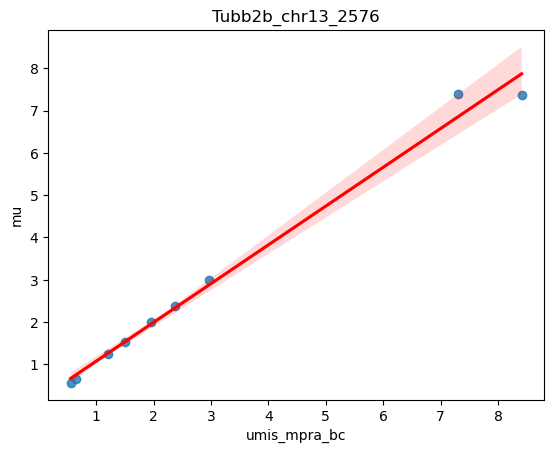

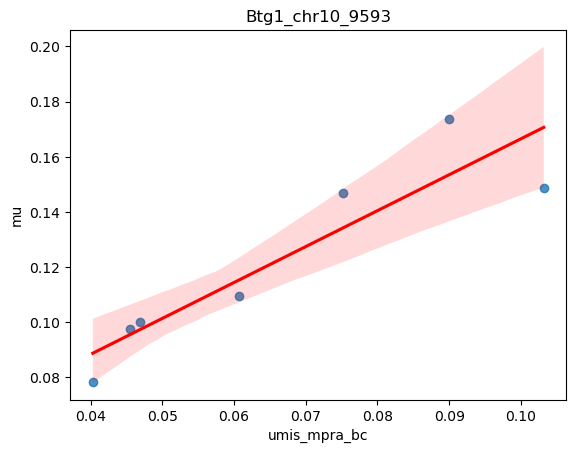

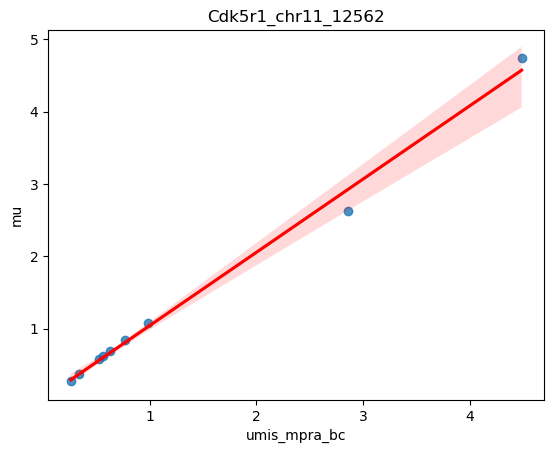

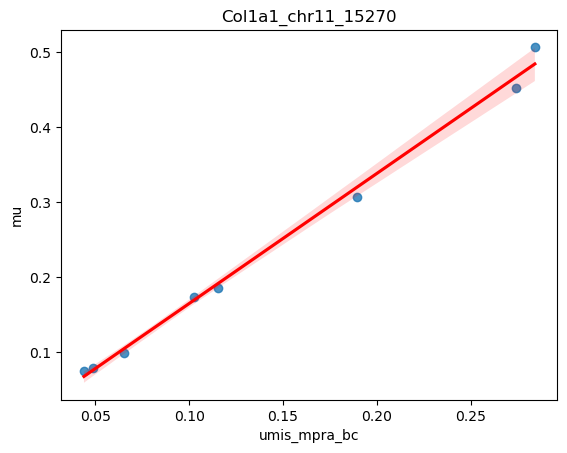

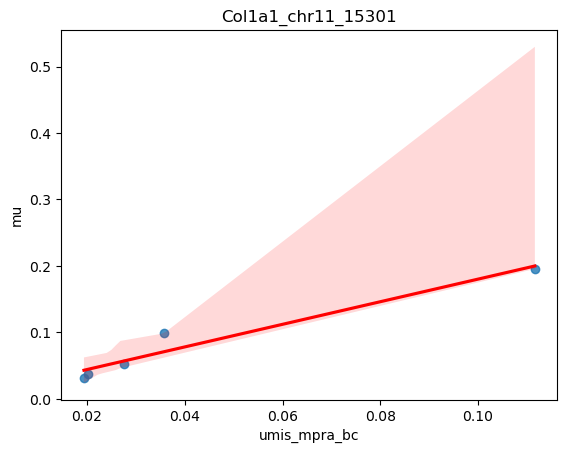

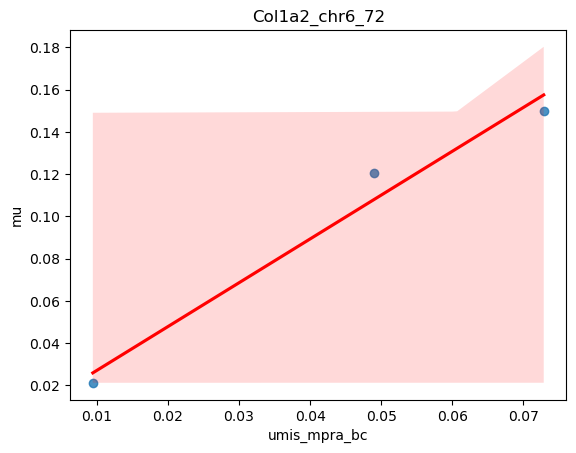

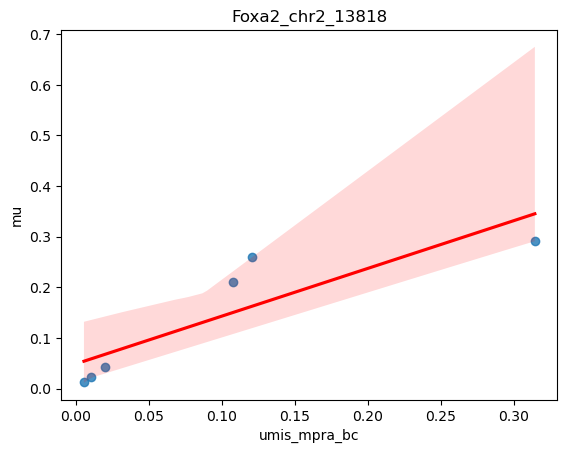

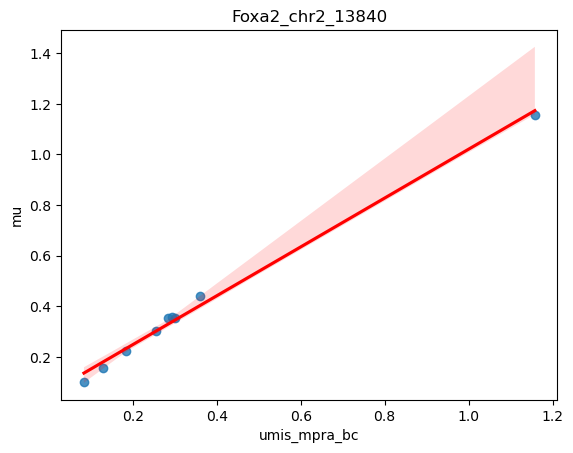

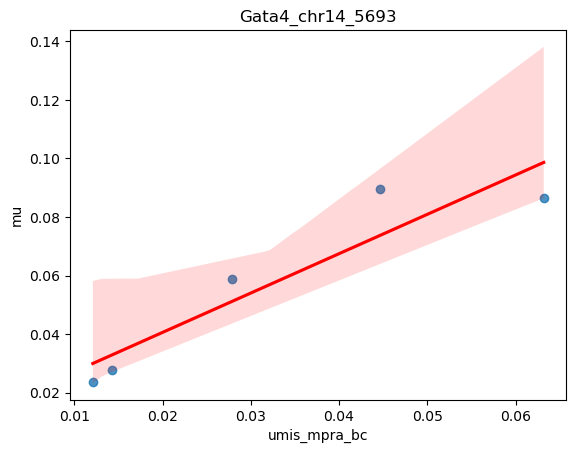

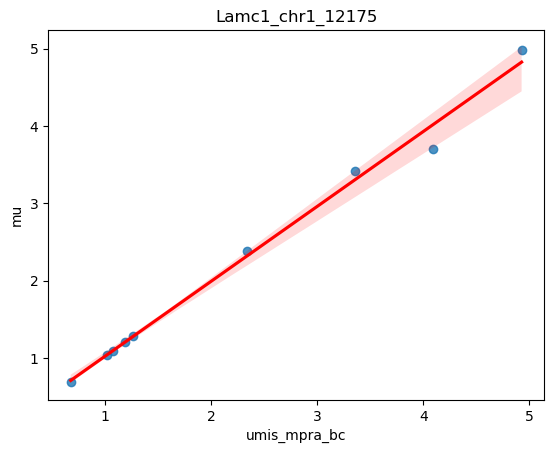

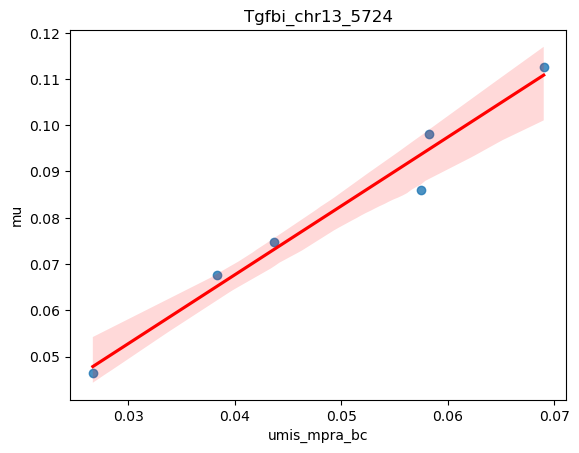

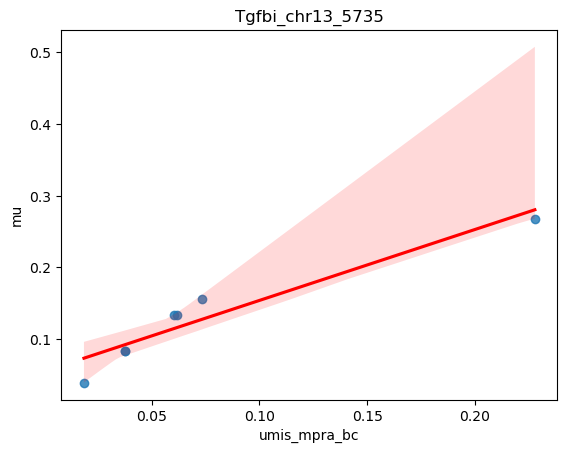

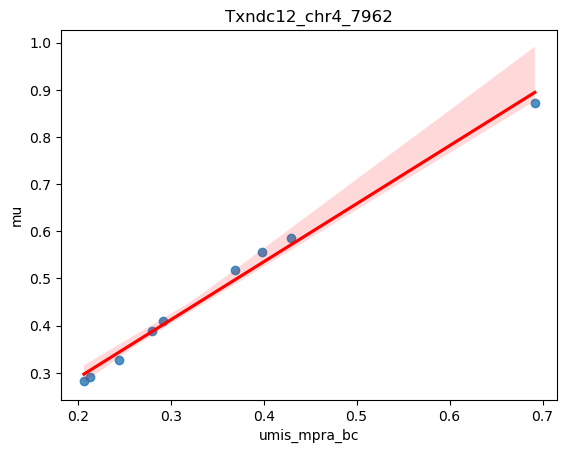

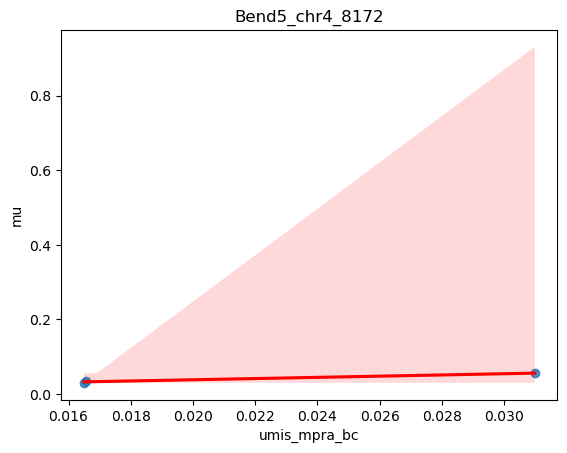

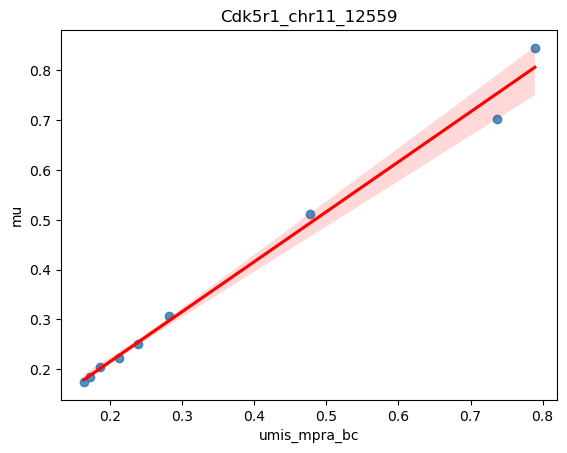

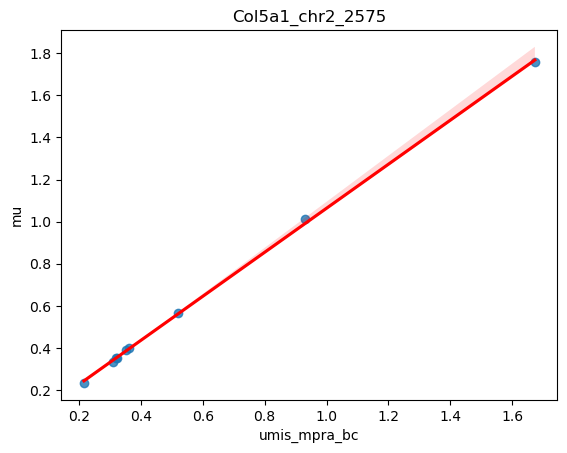

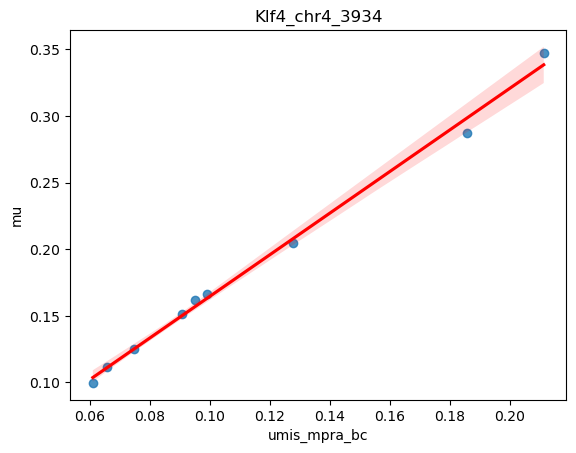

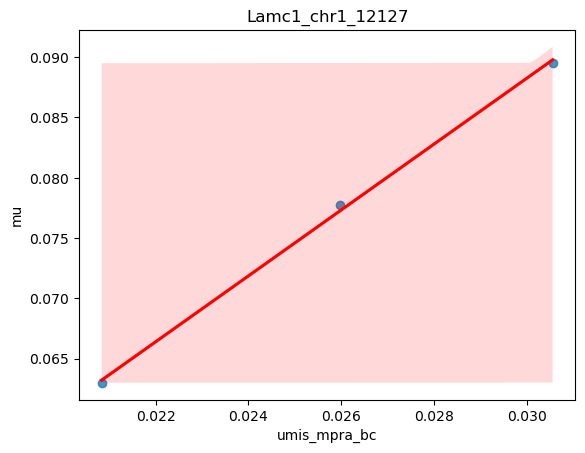

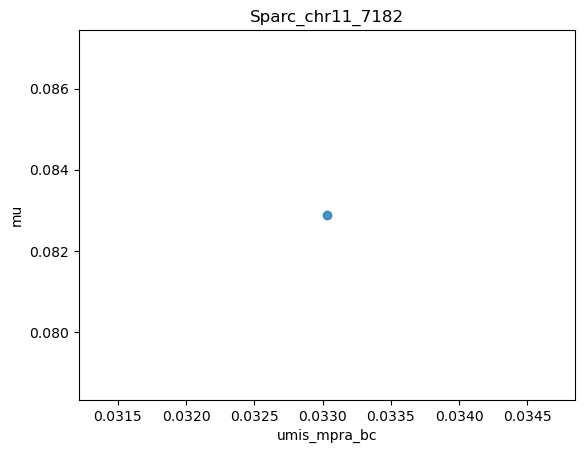

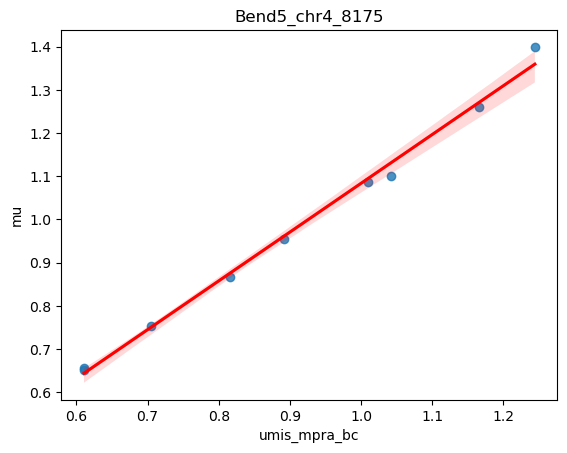

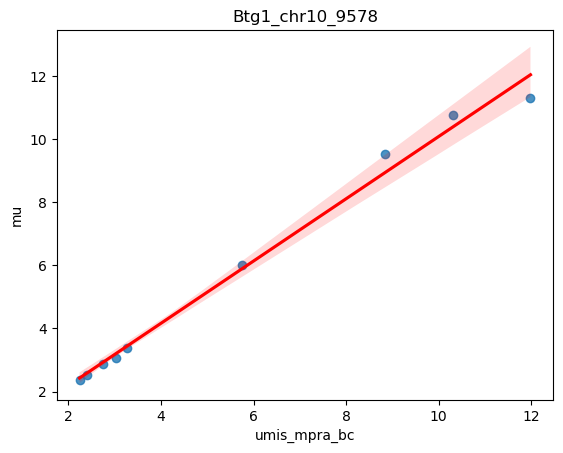

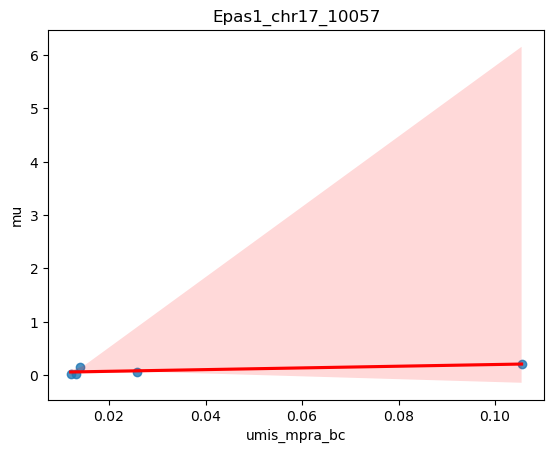

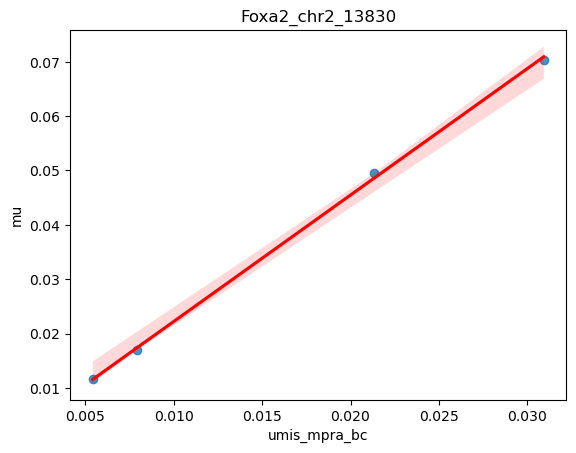

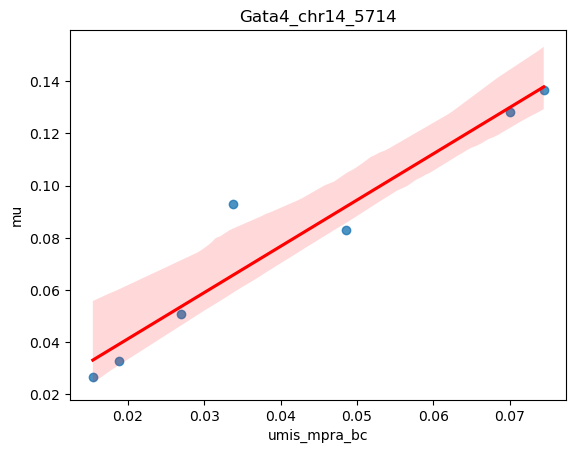

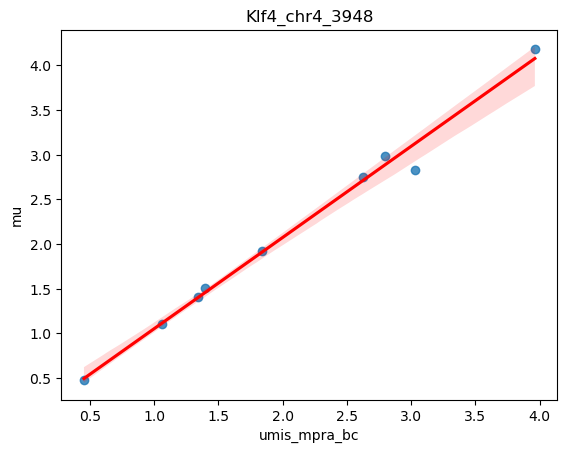

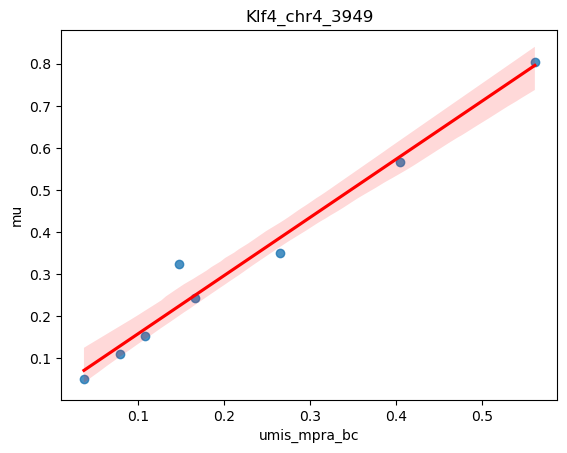

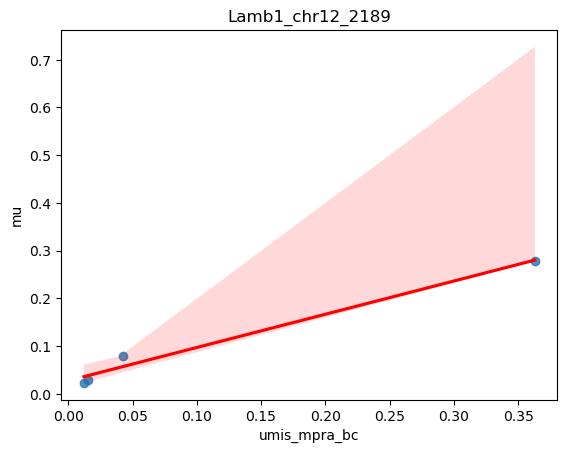

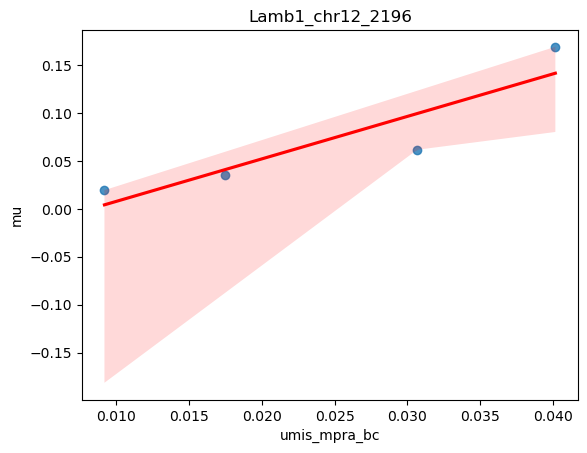

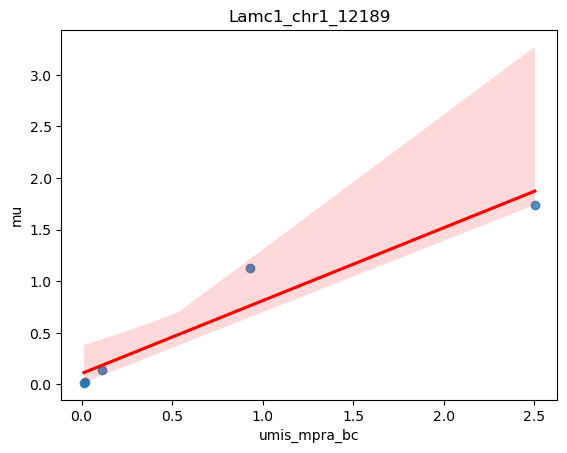

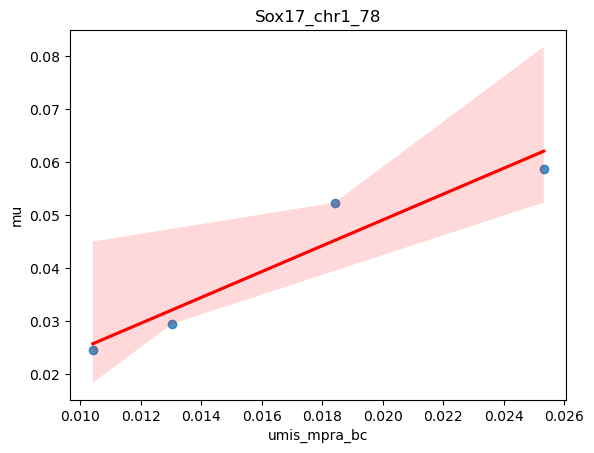

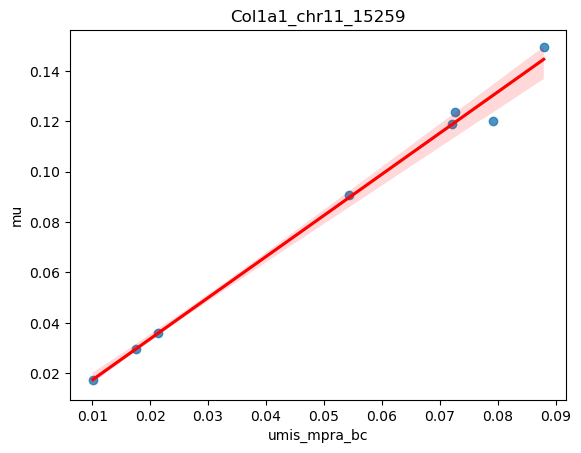

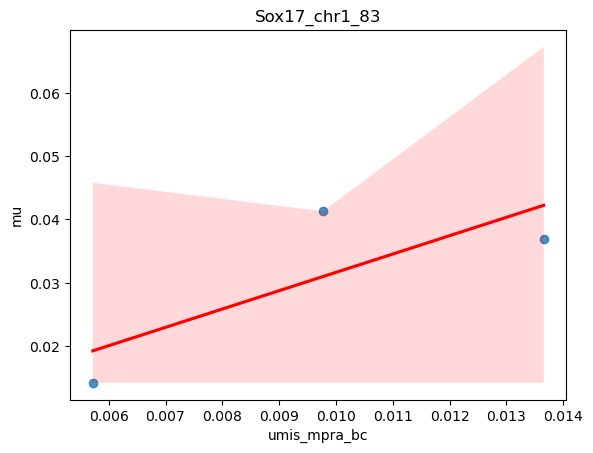

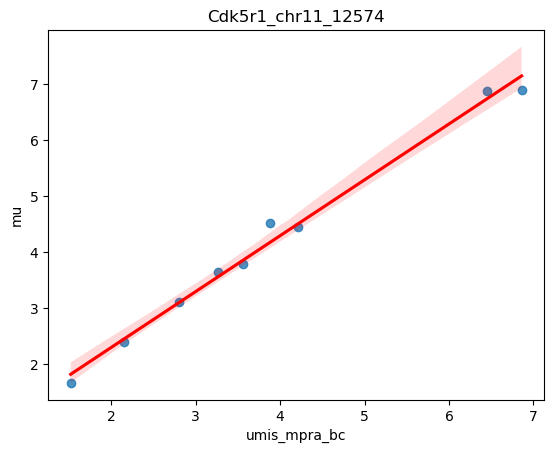

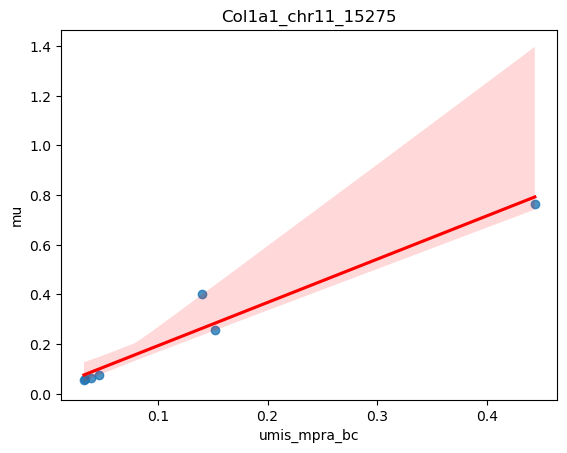

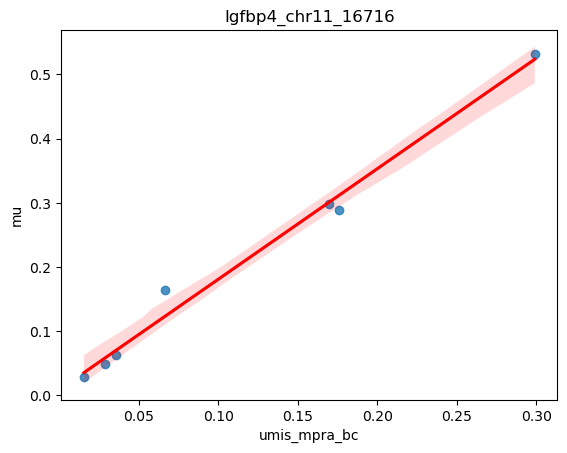

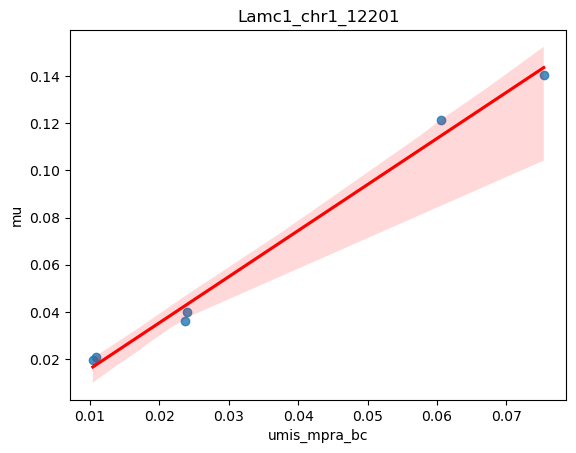

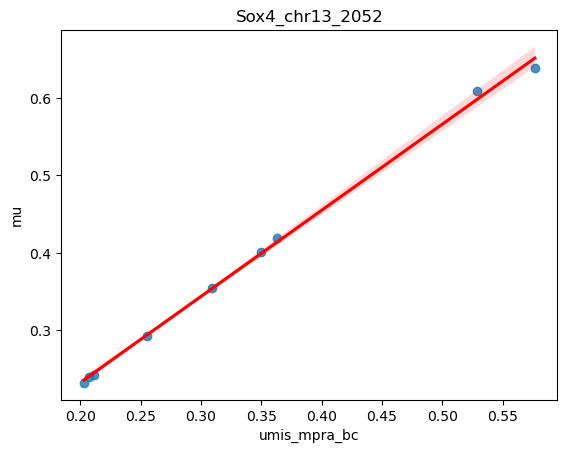

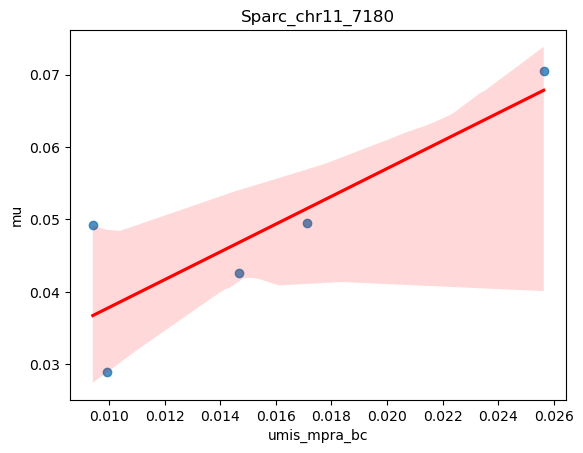

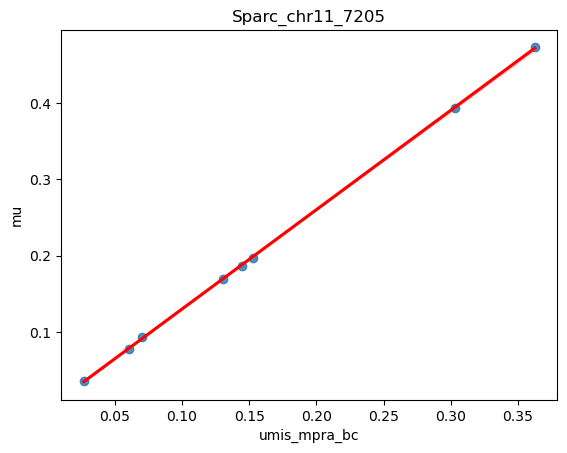

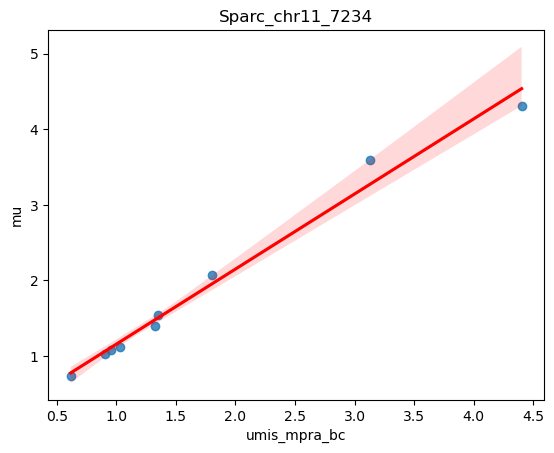

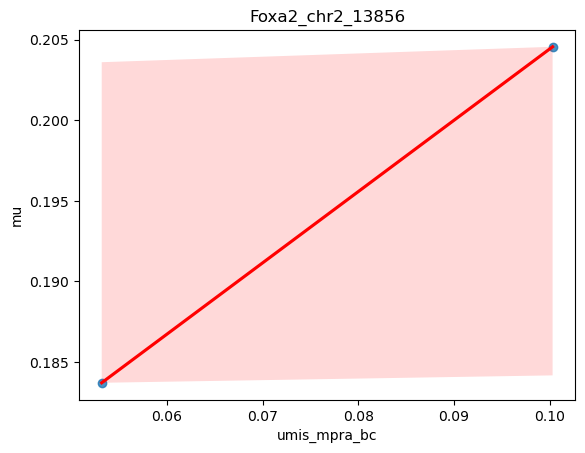

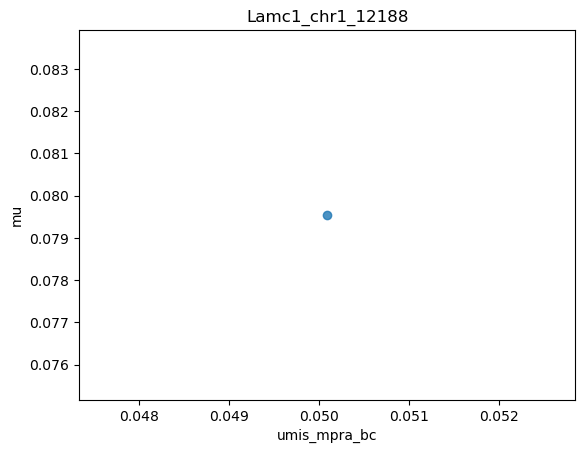

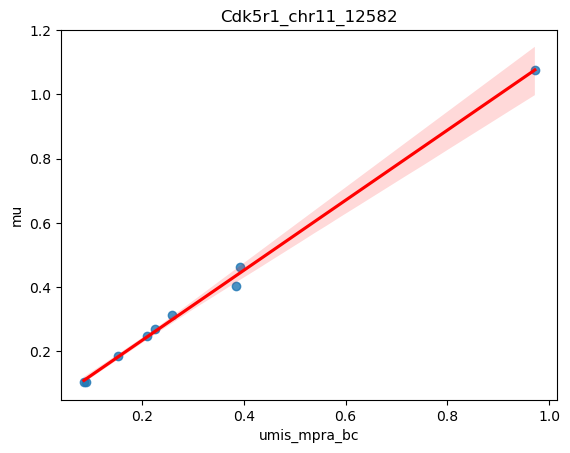

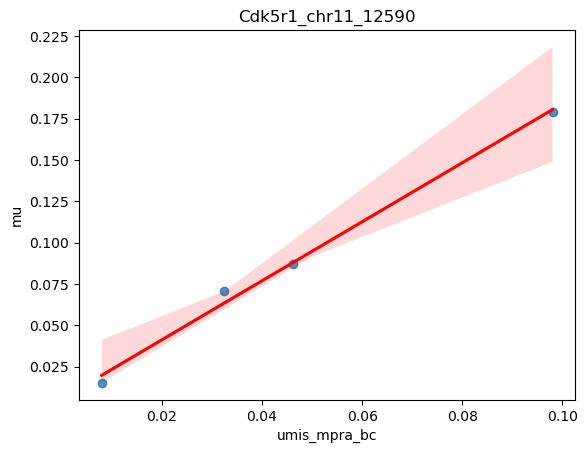

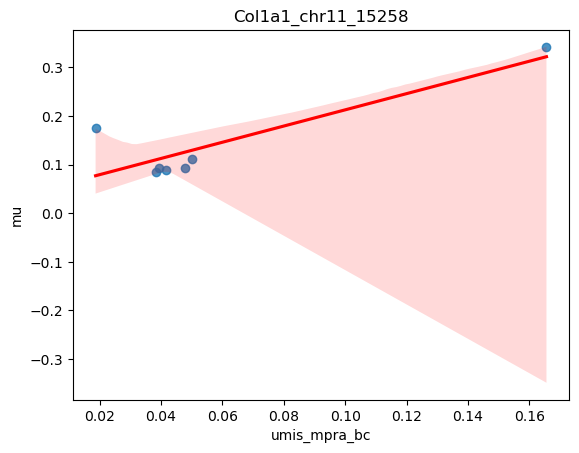

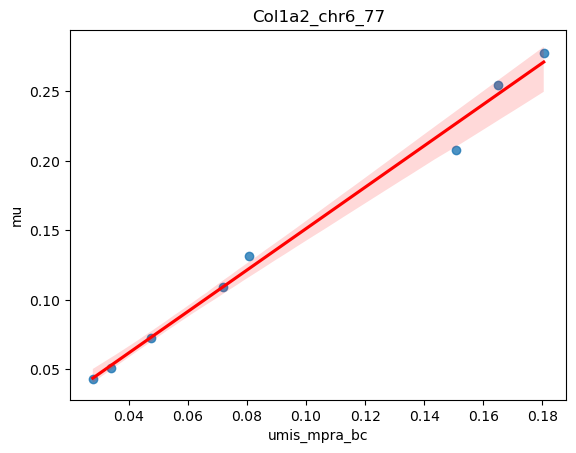

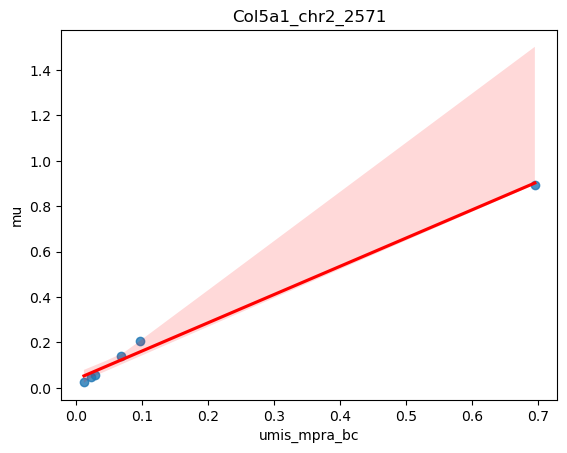

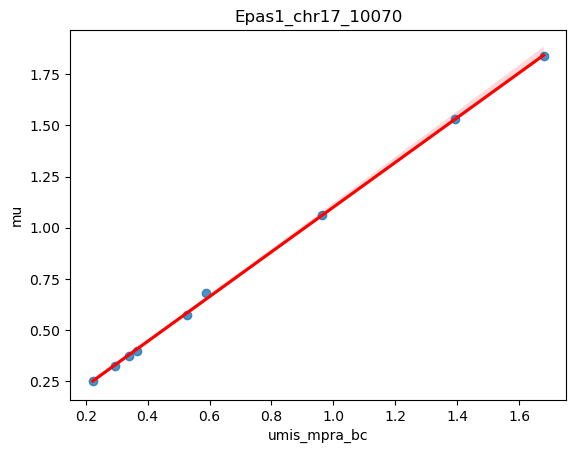

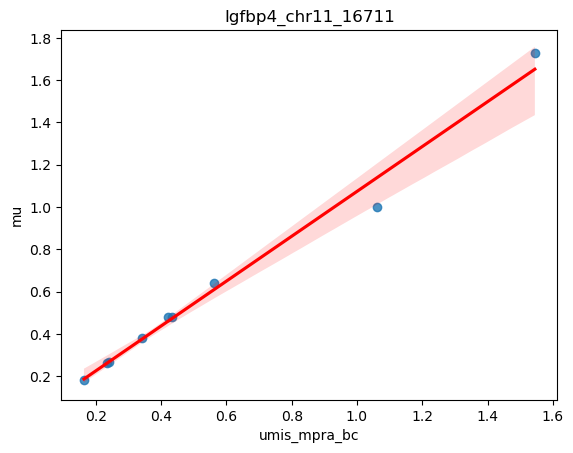

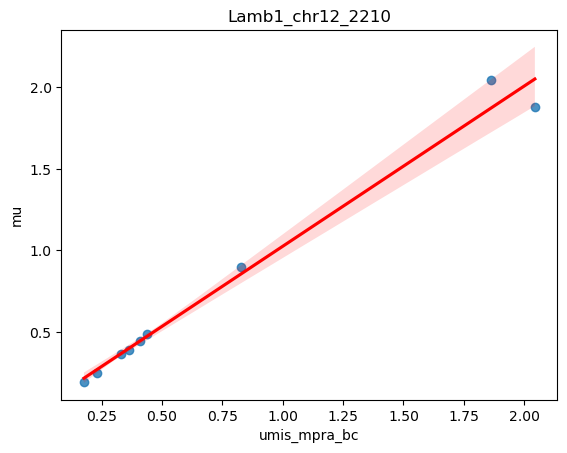

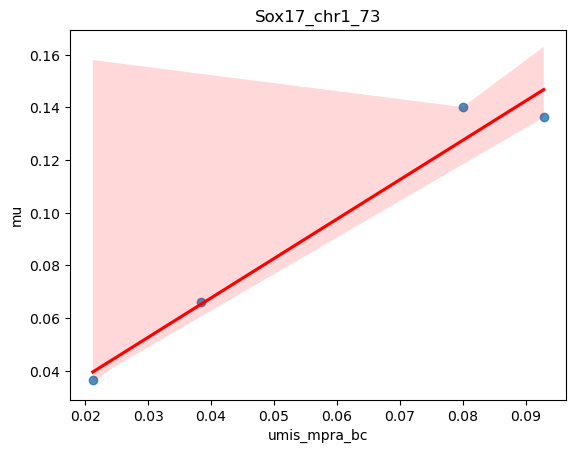

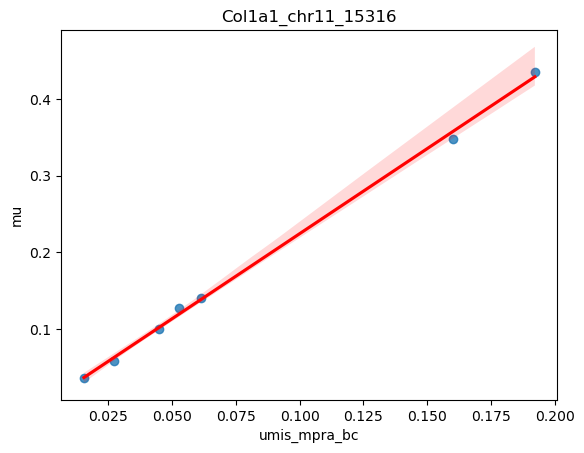

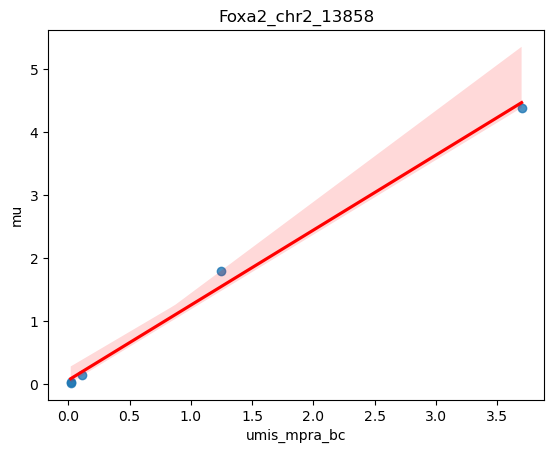

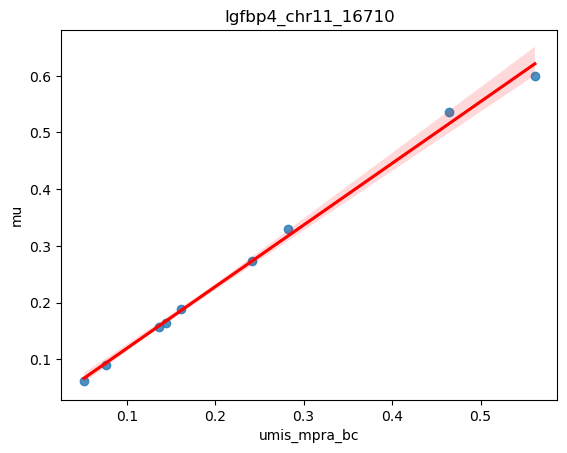

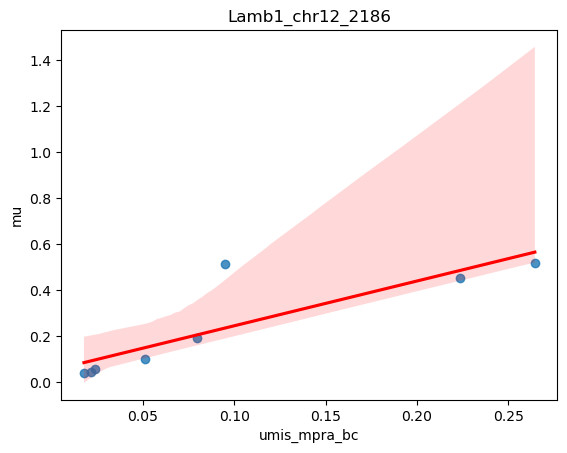

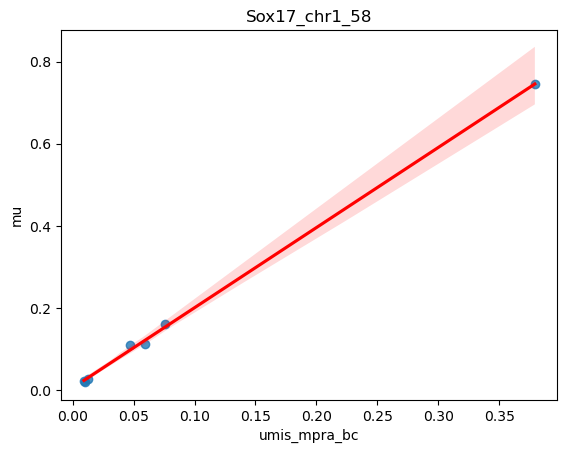

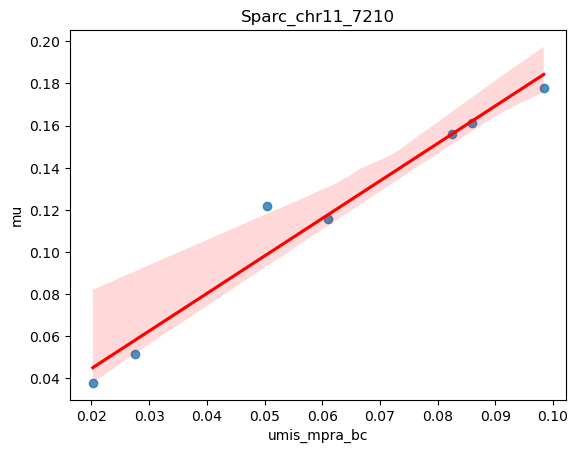

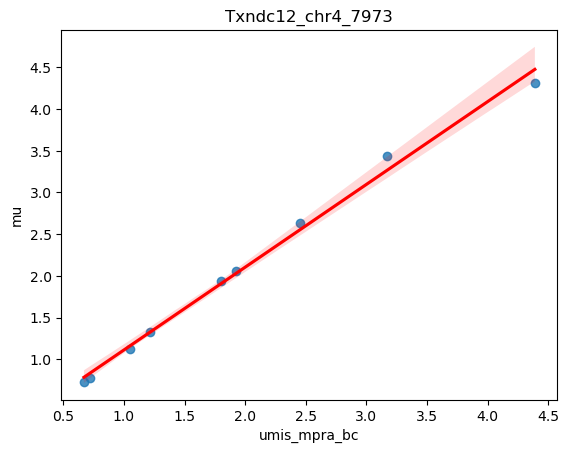

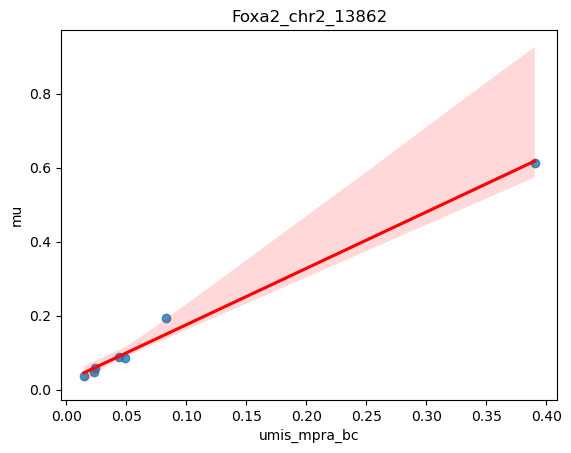

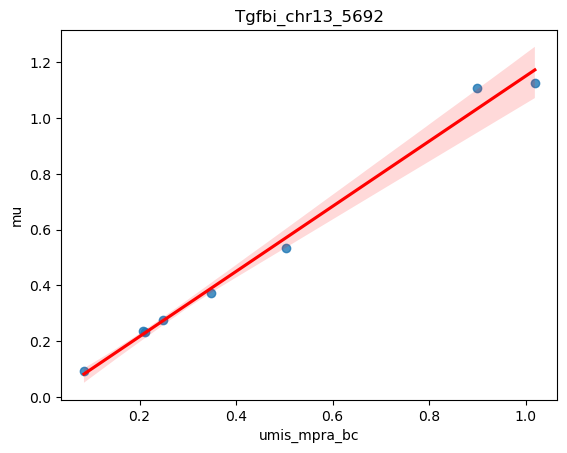

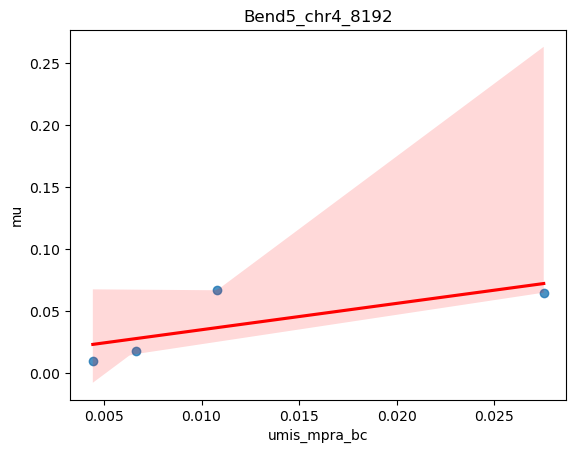

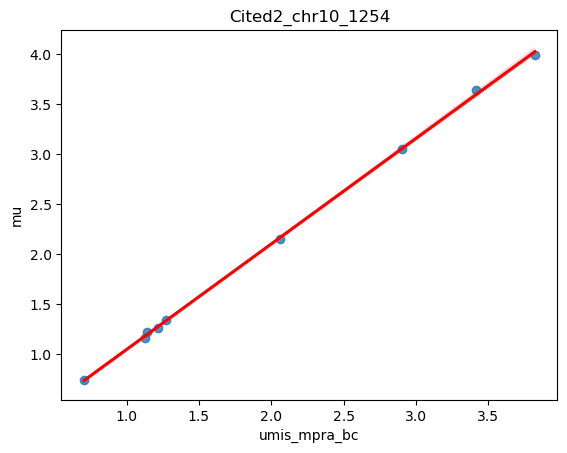

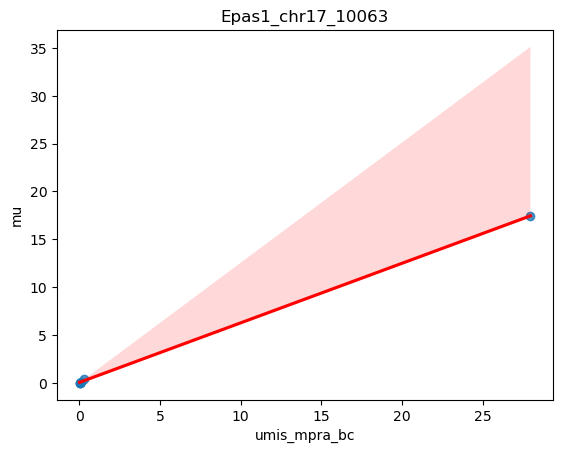

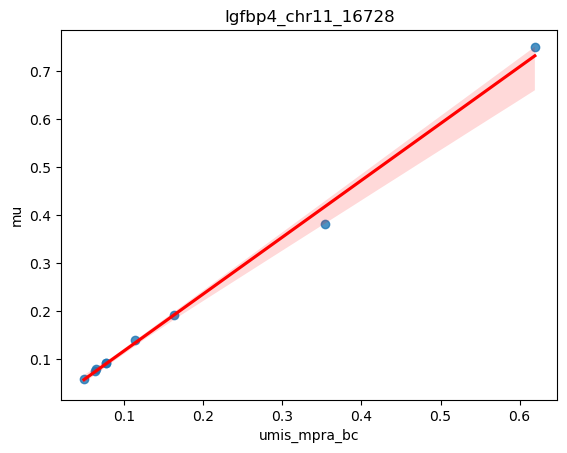

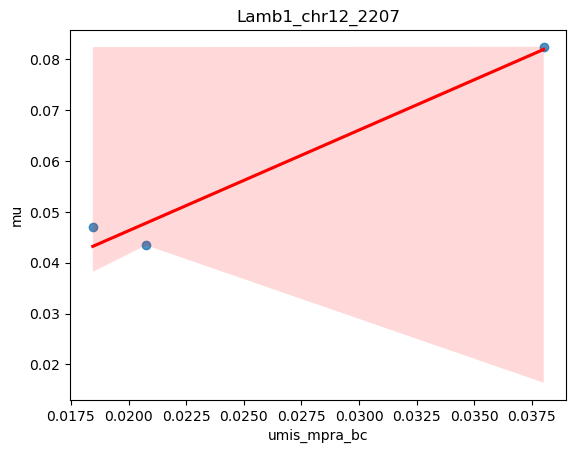

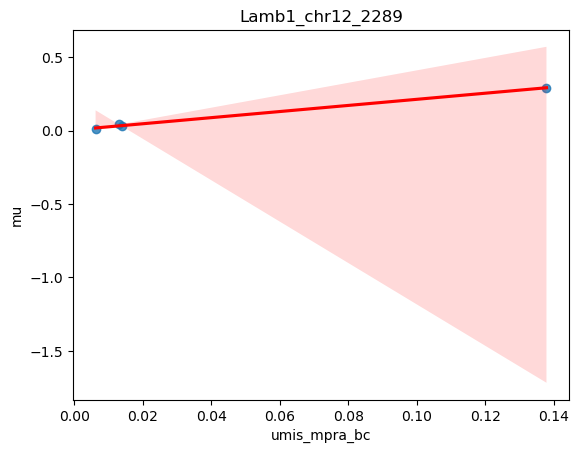

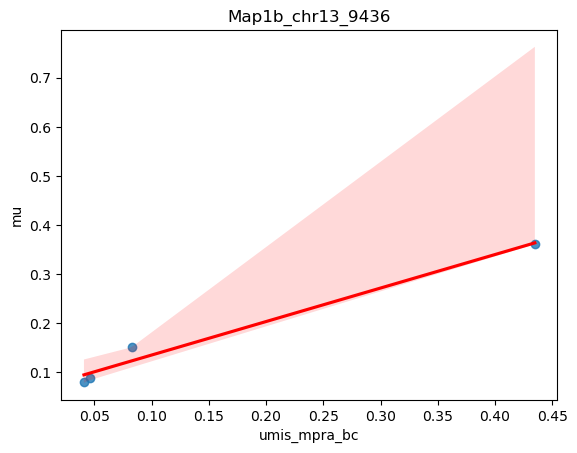

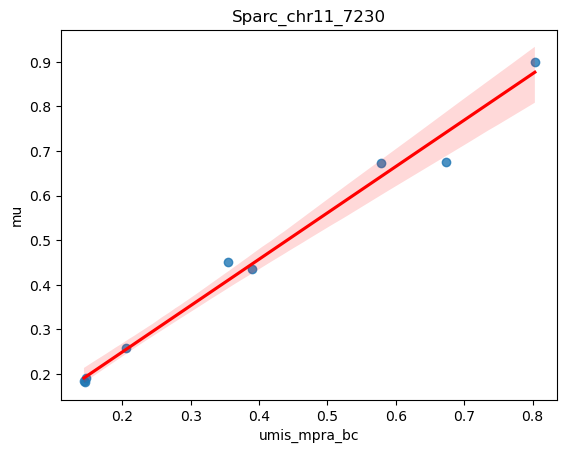

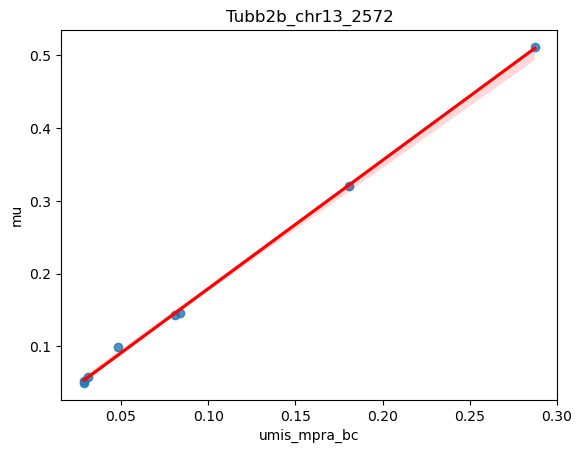

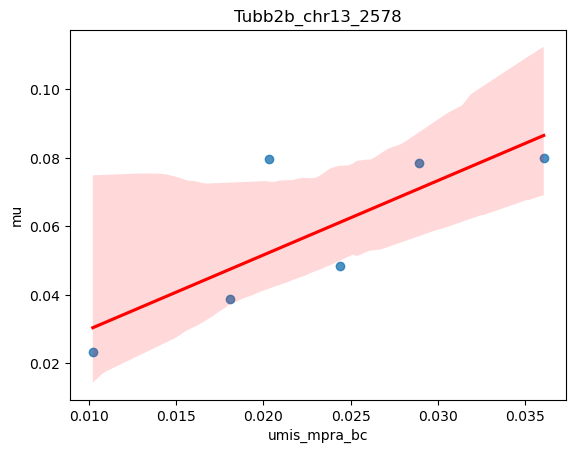

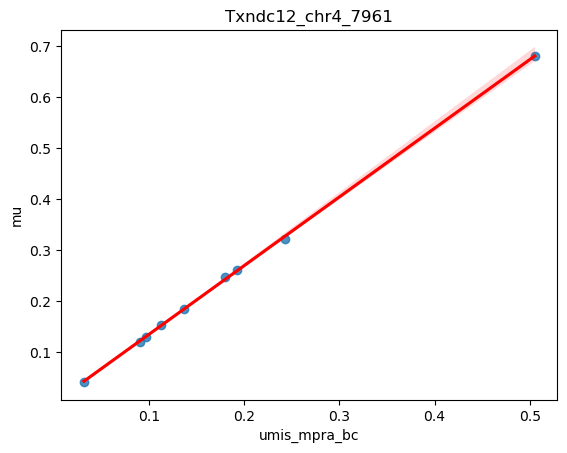

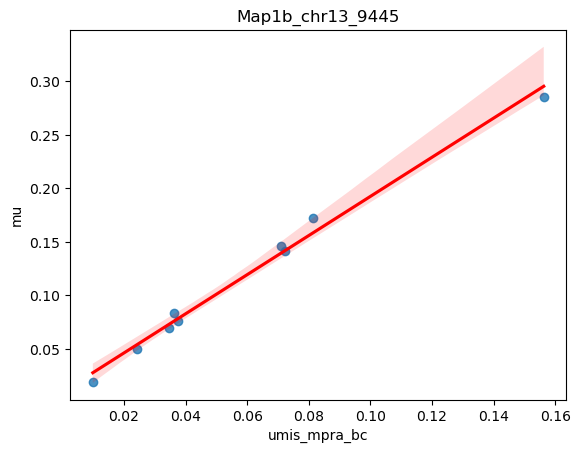

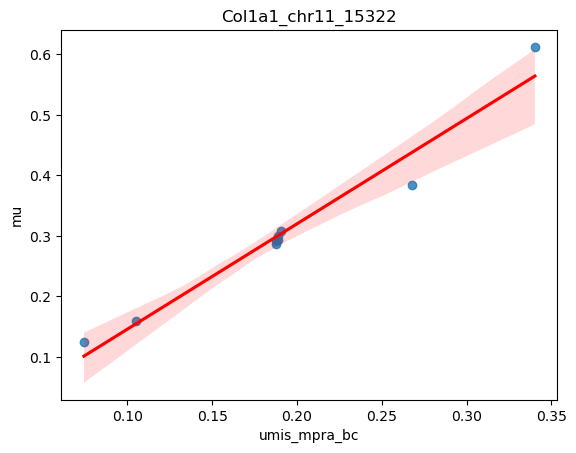

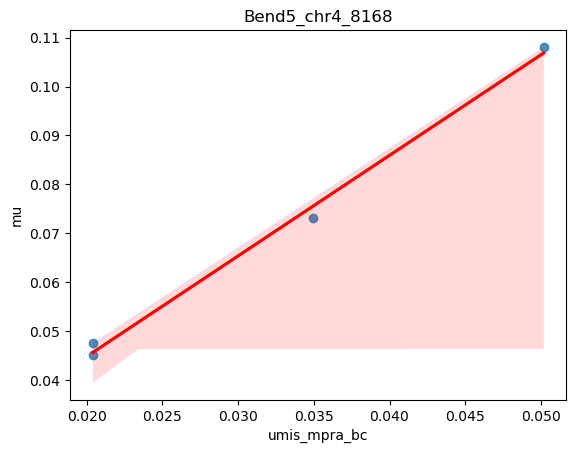

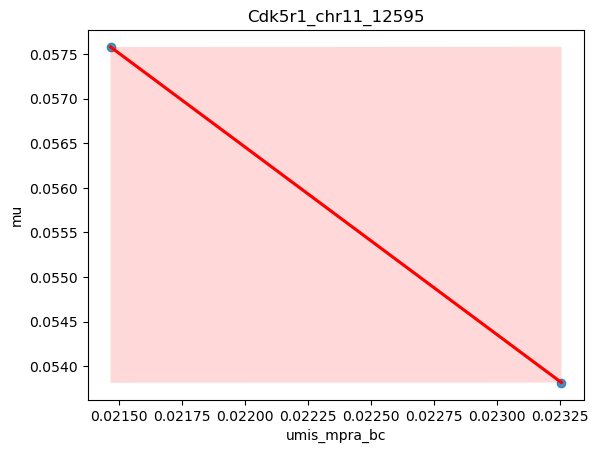

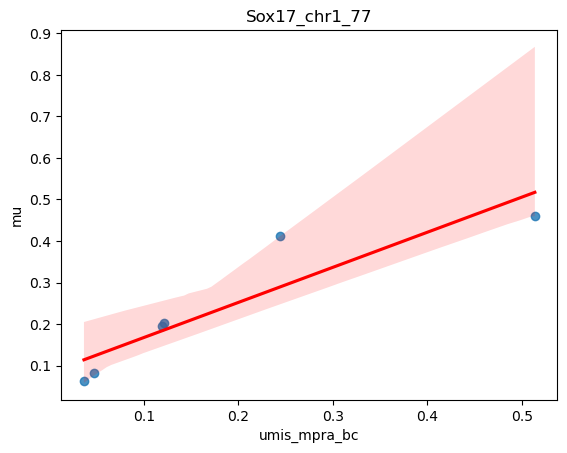

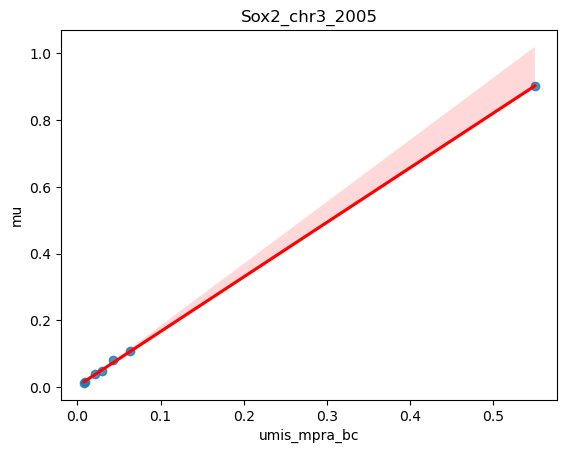

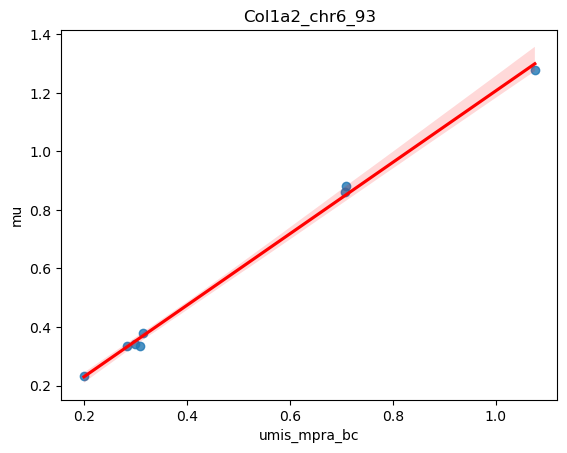

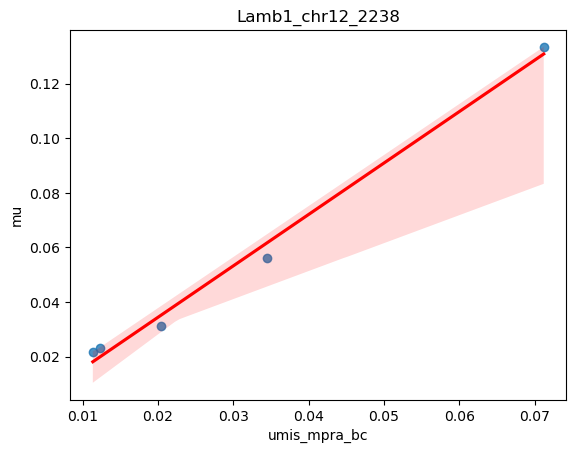

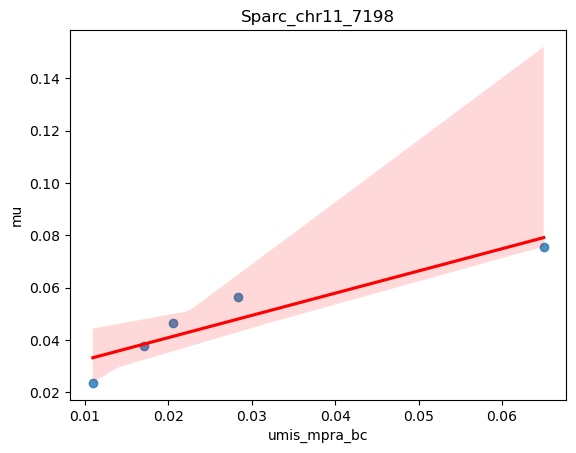

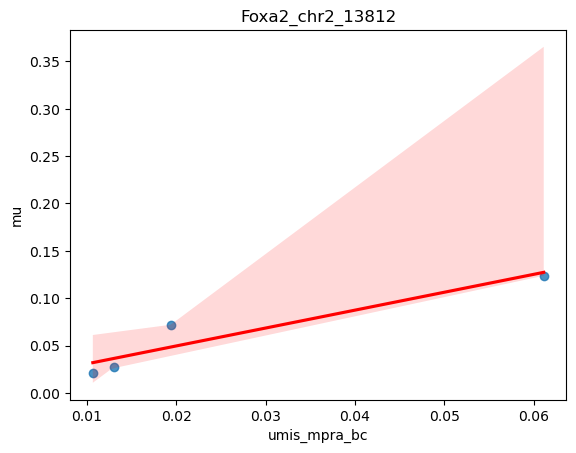

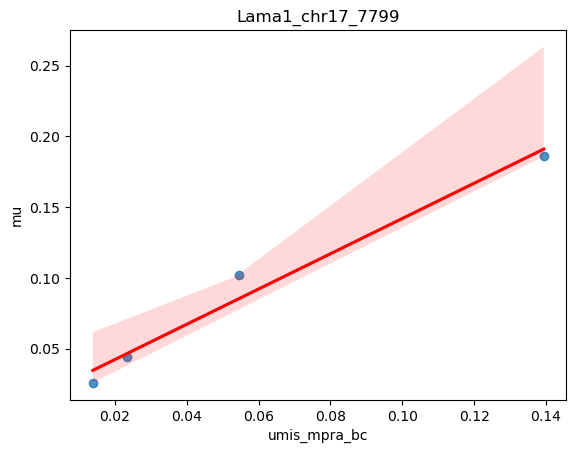

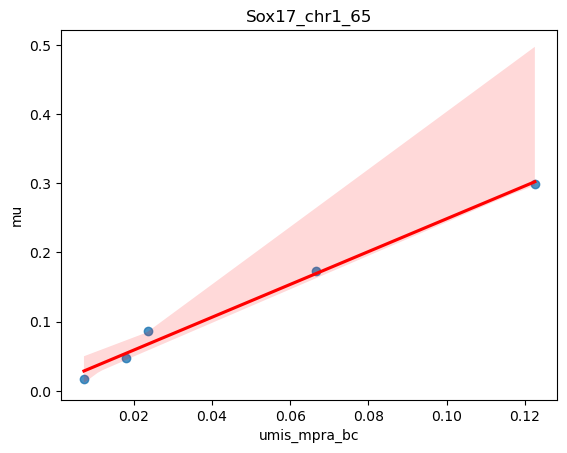

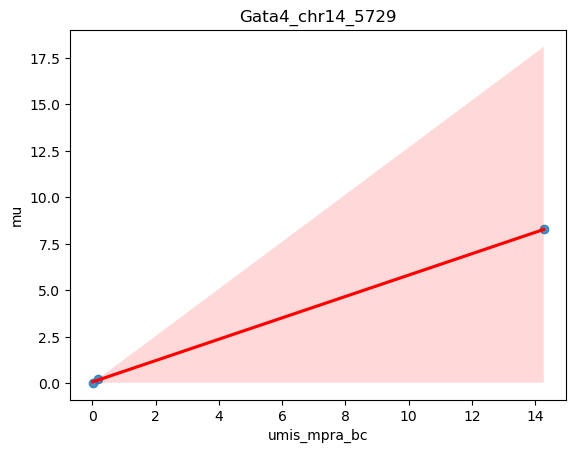

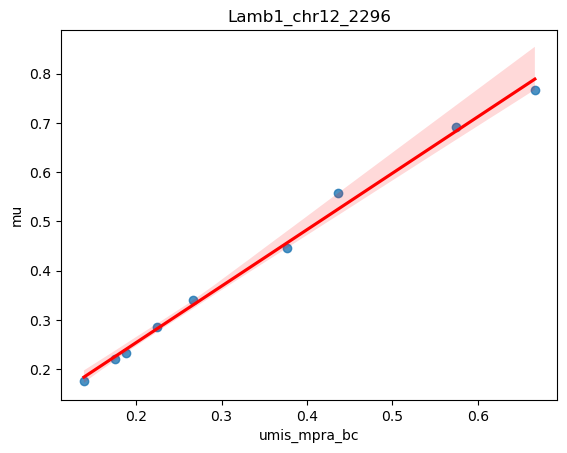

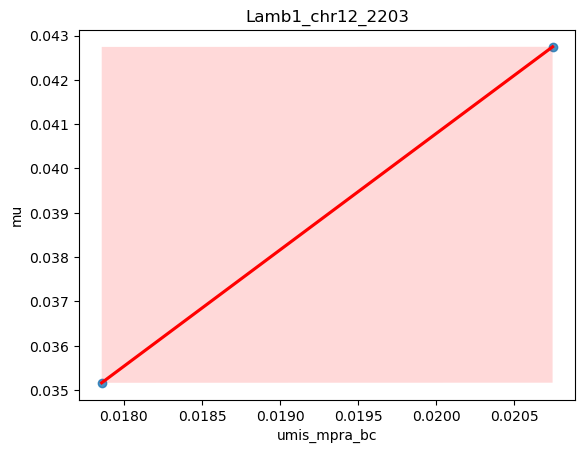

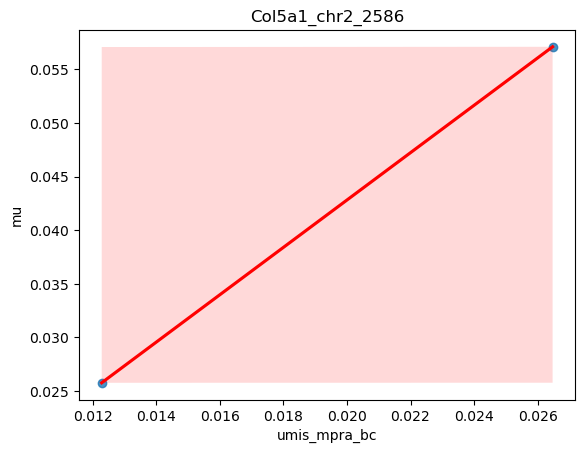

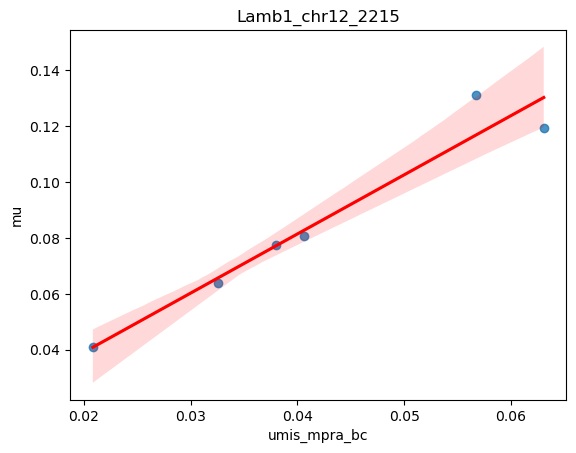

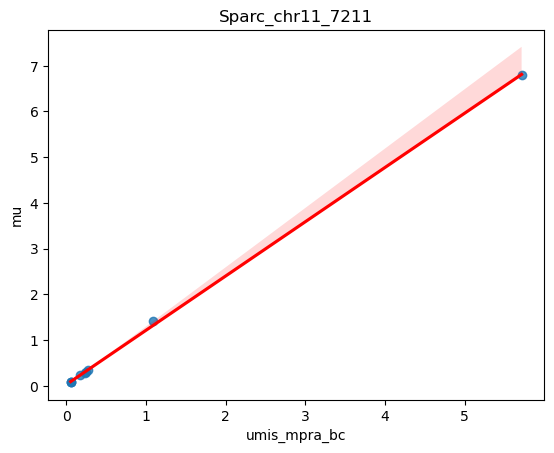

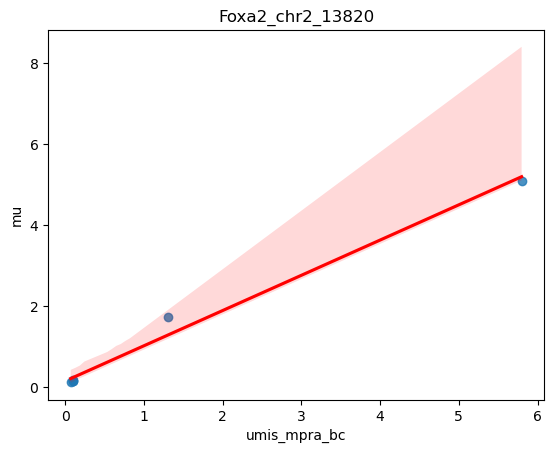

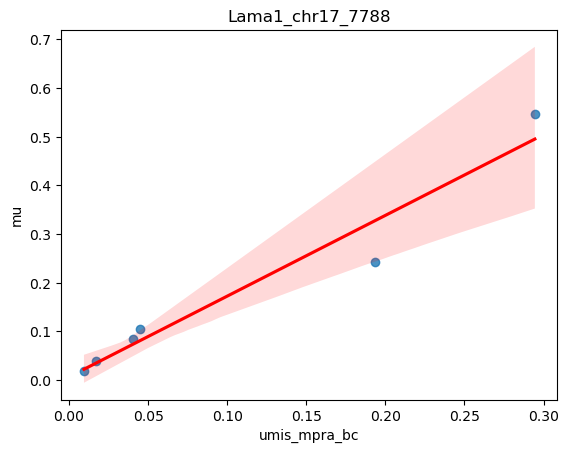

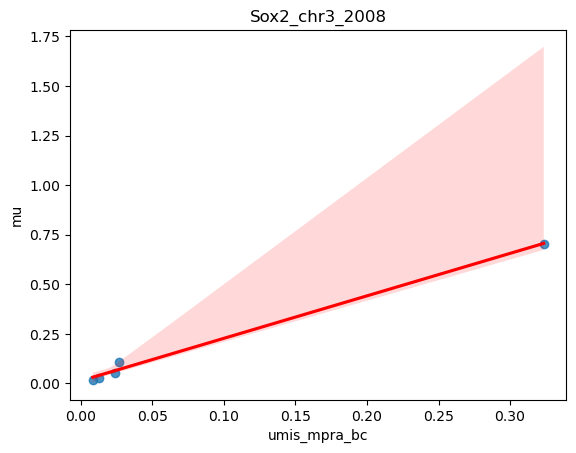

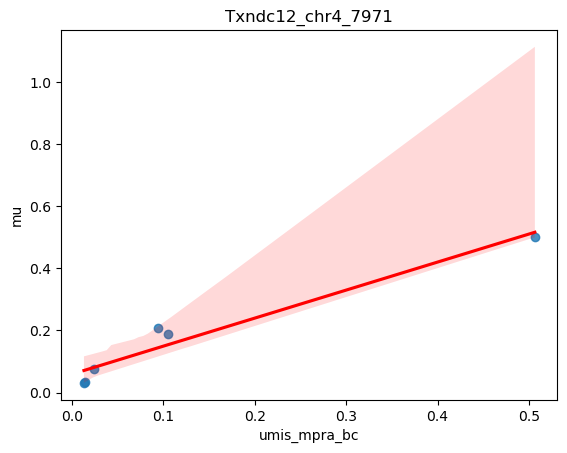

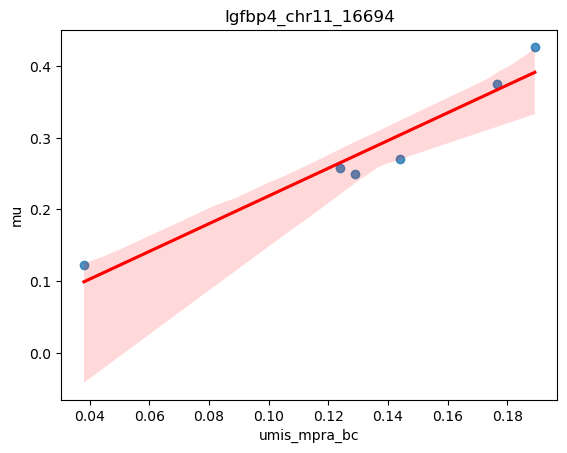

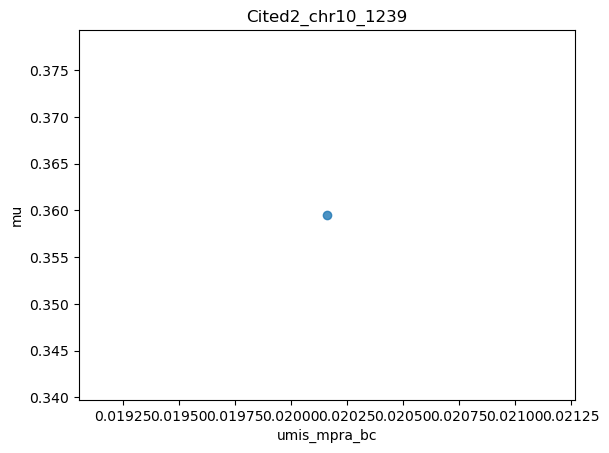

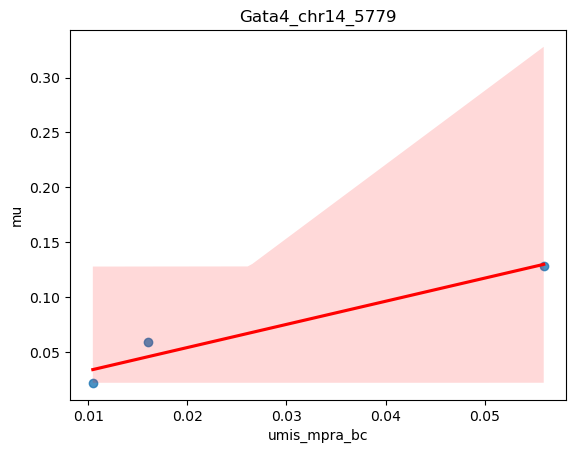

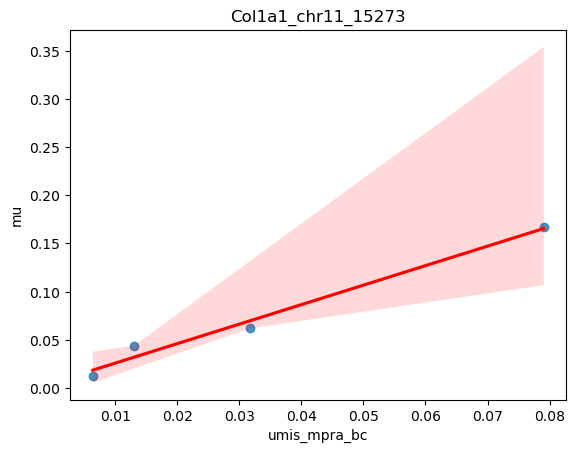

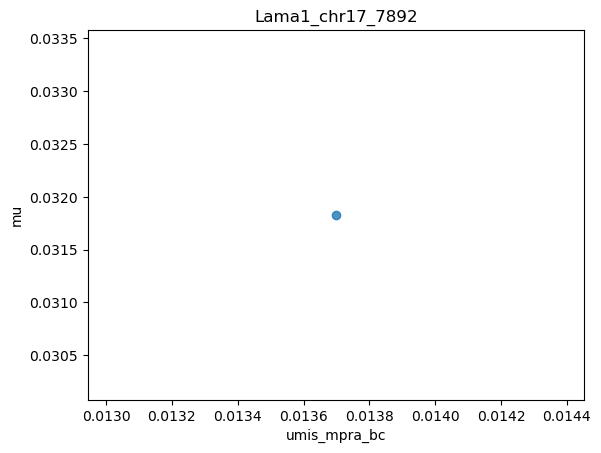

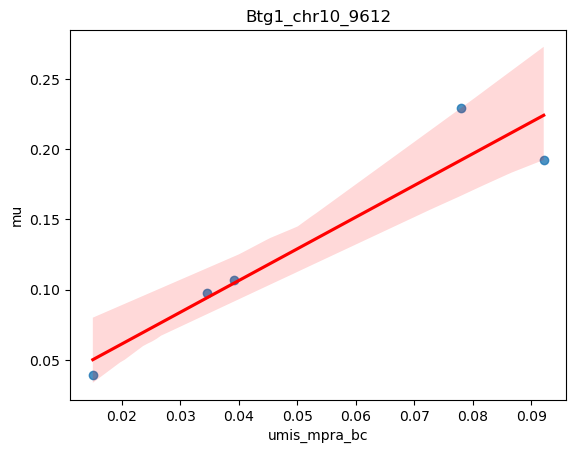

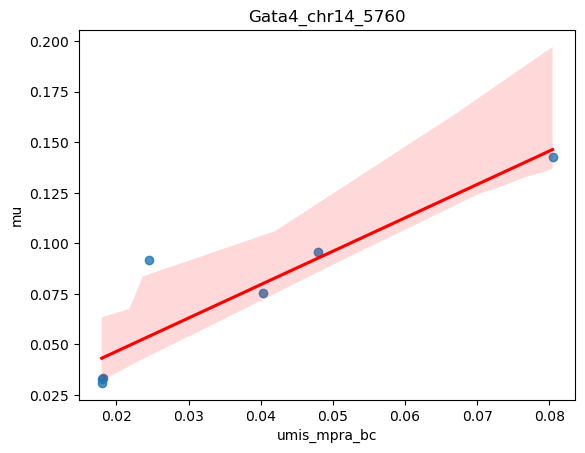

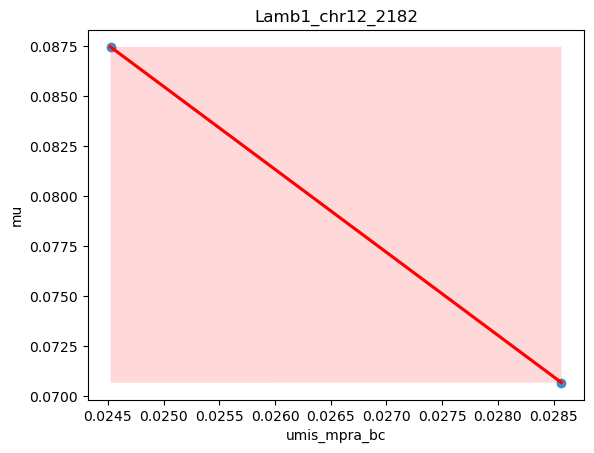

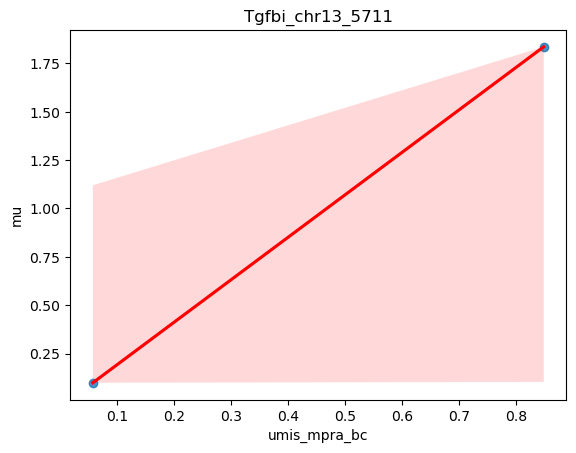

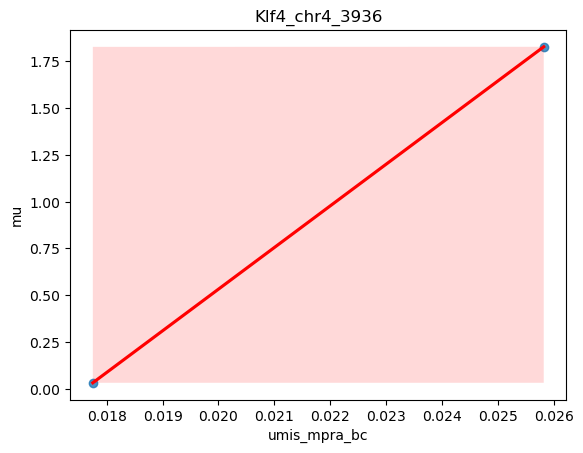

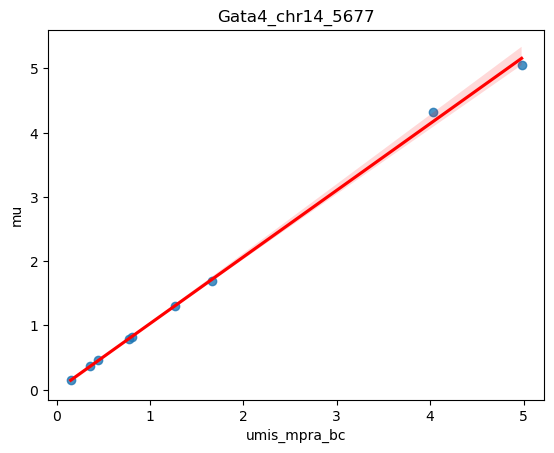

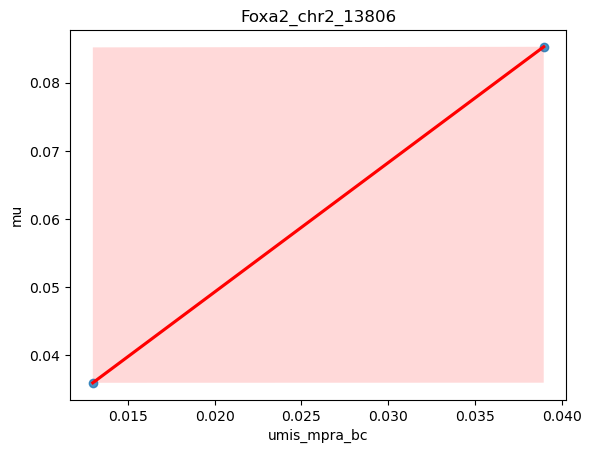

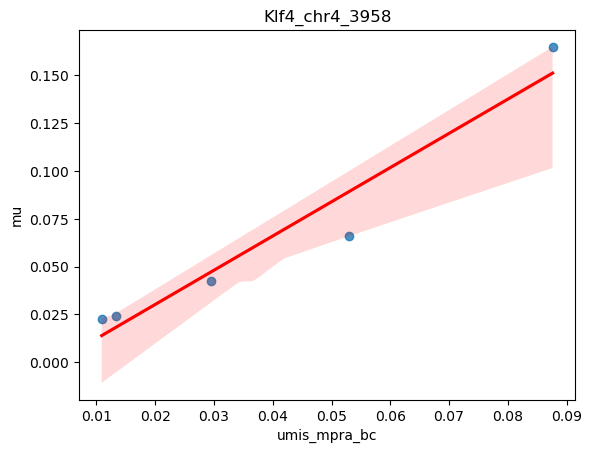

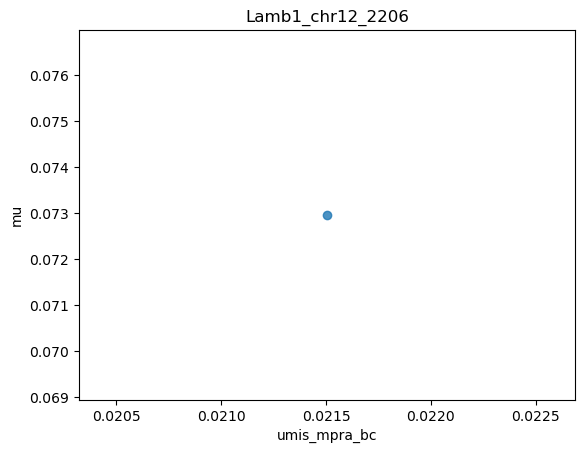

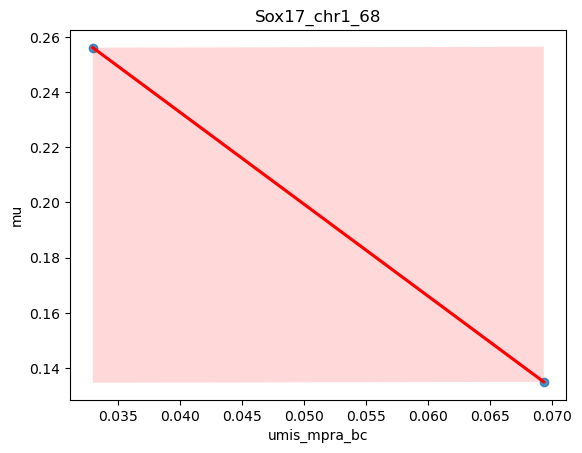

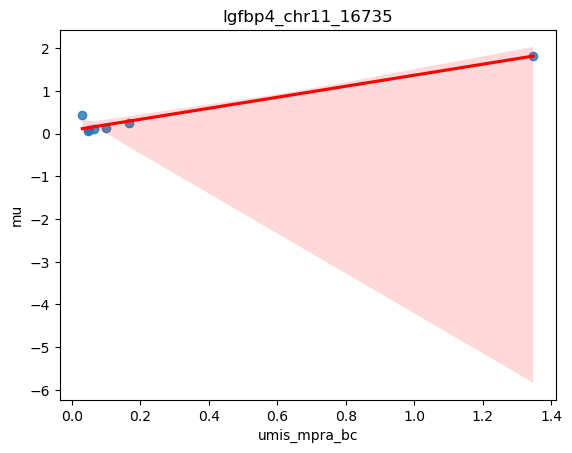

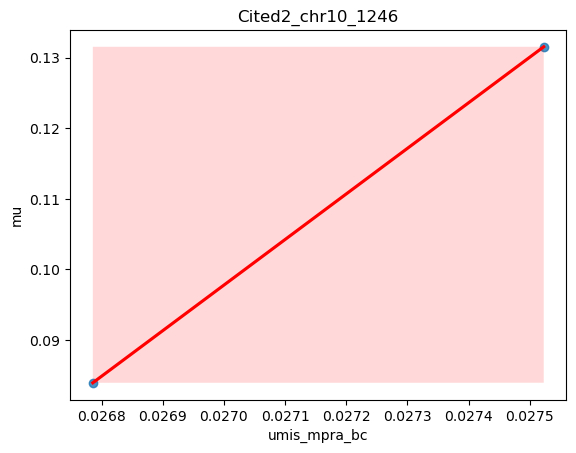

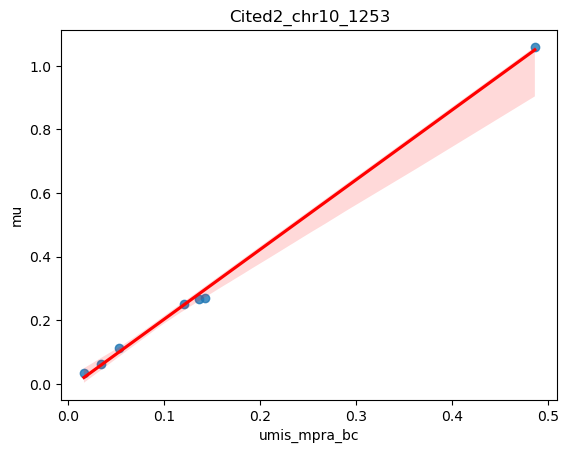

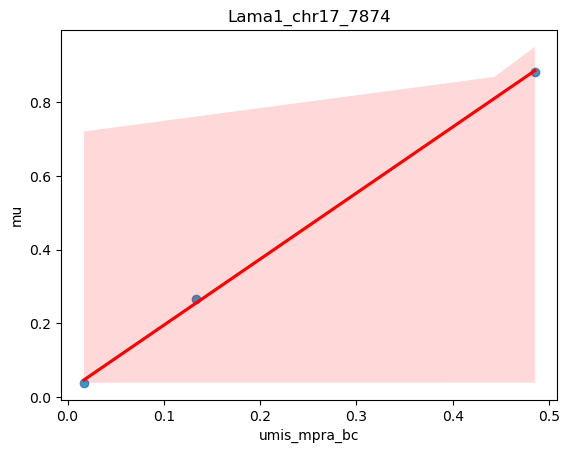

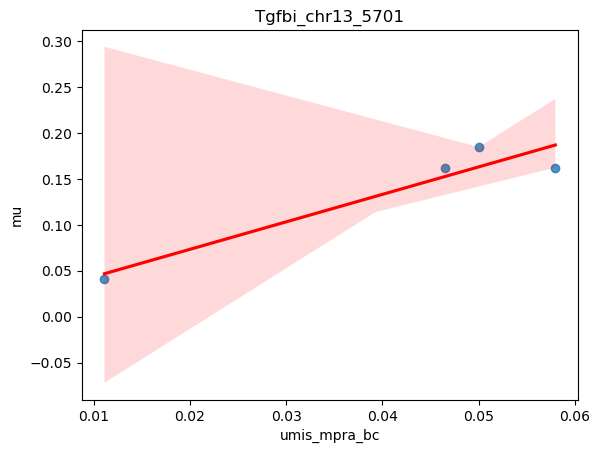

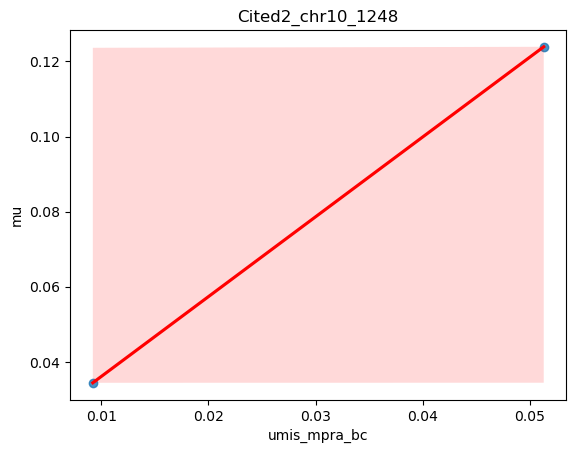

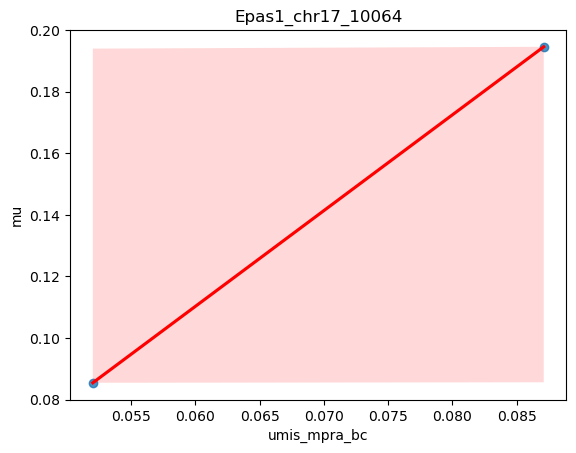

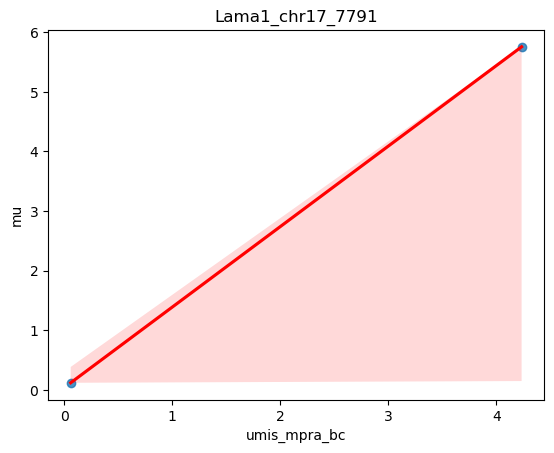

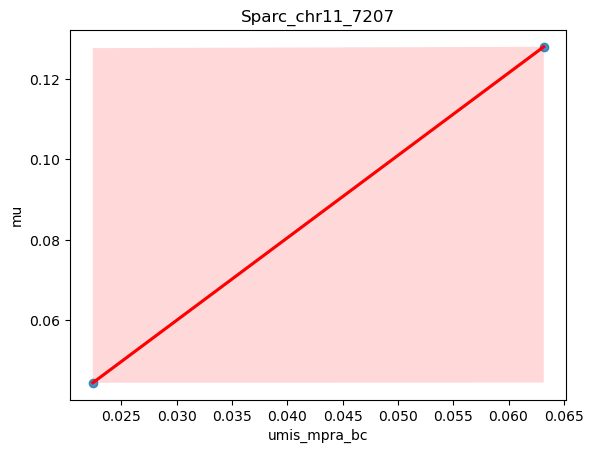

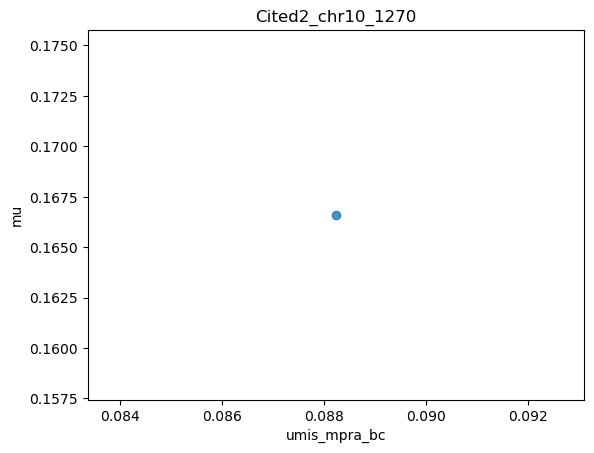

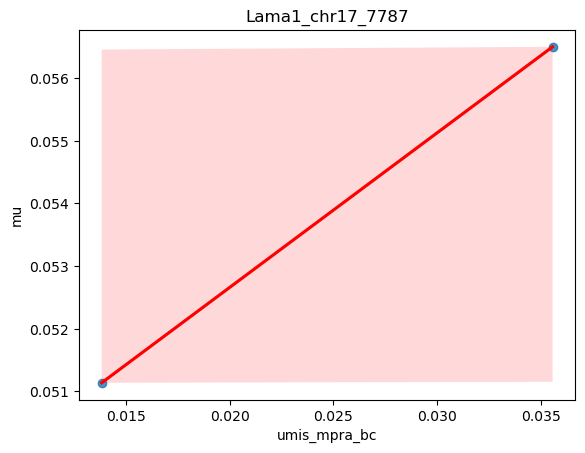

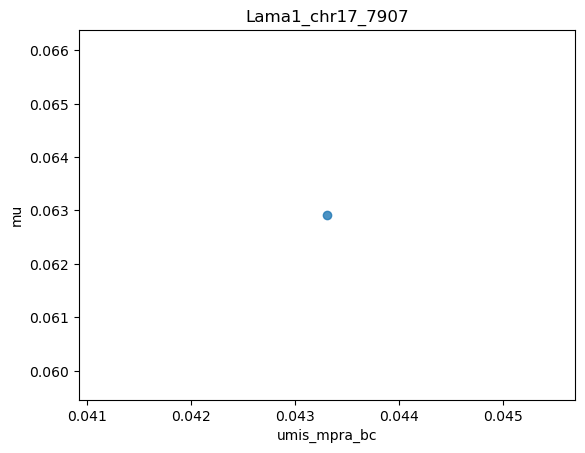

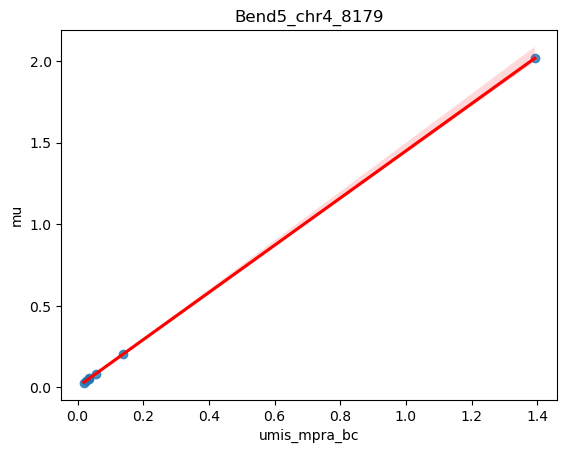

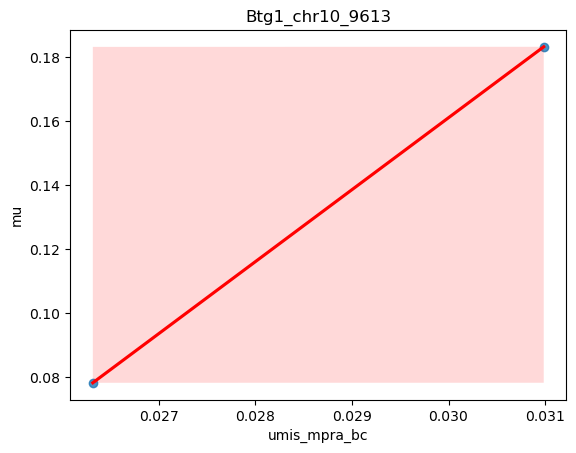

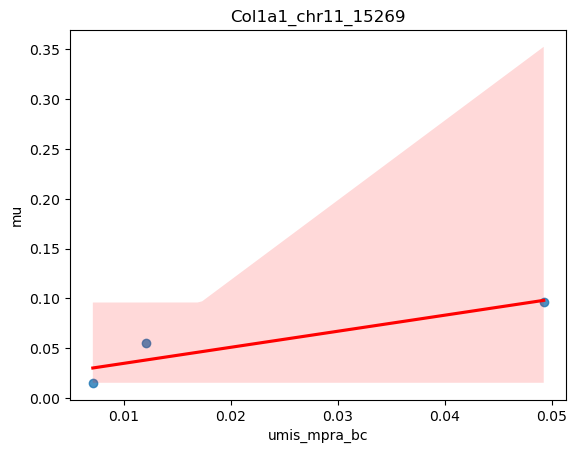

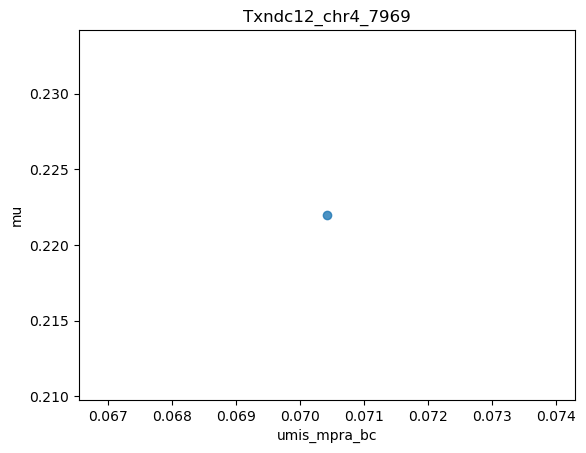

In [23]:
for cell_type in QC:
    sns.regplot(x=QC[cell_type]["x"], y=QC[cell_type]["y"], scatter=True, line_kws={"color": "red"})
    plt.title(cell_type)
    plt.show()

    #sns.regplot(x=QC[cell_type]["x"], y=QC[cell_type]["y"], scatter=True, line_kws={"color": "red"})
    #plt.title(f"Zoom {cell_type}")
    #plt.xlim(0, 20)   # Set x-axis limits
    #plt.ylim(0, 20)   # Set y-axis limits
    #plt.show()

    #sns.regplot(x=QC[cell_type]["x"], y=QC[cell_type]["y"], scatter=True, line_kws={"color": "red"})
    #plt.title(f"Xtra Zoom {cell_type}")
    #plt.xlim(0, 2.5)   # Set x-axis limits
    #plt.ylim(0, 2.5)   # Set y-axis limits
    #plt.show()

    